# Task 2 — Season Classification

**Status:** execution in progress. The protocol and notebook story are fixed; G0, B0, B1, and G1 now have measured, hash-linked evidence.

**How to finish this notebook:** implement reusable logic under `src/fashion/`; fill each code cell; run it; keep its output; then replace the prompt text after the bold Interpretation marker with a short evidence-based finding.

**Structural rule:** every leaf `###` subsection owns exactly one code cell. A broader `###` owns no direct code cell; divide it into `####` subsubsections, with one code cell per `####` leaf.

**Frozen boundaries:** teacher images only; `data/processed/splits.csv` is the only split; all submitted models are trained from scratch; all runs go through `fashion.train.registry` to `results/runs.csv`; holdout remains sealed until Notebook 06.

**Core risks:** weak-visual-signal labels, article-type shortcut learning, class imbalance, acquisition artifacts, and calibration failure.

**Primary development metric:** pooled out-of-fold macro-F1 over `Fall`, `Spring`, `Summer`, and `Winter`.

## 1. Task contract and reproducibility

Freeze the decision, labels, paths, seed, and execution environment before any result is viewed.

### 1.1 Frozen task configuration

This cell creates the single configuration object used by every later cell.

In [1]:
import hashlib
import json

import pandas as pd
from IPython.display import display

from fashion.config import (
    CV_FOLD_SUMMARY_JSON,
    RANDOM_SEED,
    ROOT,
    TASK2_CHECKPOINT_DIR,
    TASK2_EVIDENCE_DIR,
    TASK2_FIGURE_DIR,
    TASK2_MODEL_PATH,
    TASK2_SELECTION_FREEZE_JSON,
)
from fashion.data.dataset import load_label_maps

TASK2_TARGET = "season"
SEASON_MASK = "has_season_label"
SEASON_LABELS = tuple(load_label_maps()[TASK2_TARGET]["classes"])
assert SEASON_LABELS == ("Fall", "Spring", "Summer", "Winter")

with CV_FOLD_SUMMARY_JSON.open(encoding="utf-8") as handle:
    cv_summary = json.load(handle)
for directory in (TASK2_EVIDENCE_DIR, TASK2_FIGURE_DIR, TASK2_CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

task_contract = pd.DataFrame(
    [{
        "target": TASK2_TARGET,
        "labels": " | ".join(SEASON_LABELS),
        "seed": RANDOM_SEED,
        "cv_folds": cv_summary["fold_count"],
        "cv_assignment_sha256": cv_summary["cv_assignment_sha256"],
        "evidence_directory": TASK2_EVIDENCE_DIR.relative_to(ROOT).as_posix(),
        "figure_directory": TASK2_FIGURE_DIR.relative_to(ROOT).as_posix(),
        "checkpoint_directory": TASK2_CHECKPOINT_DIR.relative_to(ROOT).as_posix(),
        "freeze_manifest": TASK2_SELECTION_FREEZE_JSON.relative_to(ROOT).as_posix(),
        "final_model": TASK2_MODEL_PATH.relative_to(ROOT).as_posix(),
    }]
)
assert task_contract.loc[0, "cv_folds"] == 5
display(task_contract)

,target,labels,seed,cv_folds,cv_assignment_sha256,evidence_directory,figure_directory,checkpoint_directory,freeze_manifest,final_model
0,season,Fall | Spring | Summer | Winter,2753,5,bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c...,results/evidence/task2,results/figures/task2,tmp/task2/checkpoints,results/evidence/task2/selection_freeze.json,models/task2_season.pt


> **Interpretation to write after running:** Confirm that the output matches the assignment contract. Explain that inference is image-only and that the official CSV must always contain one Season label.

### 1.2 Environment and deterministic execution

Package versions, hardware, and random state must be recorded so runs can be reproduced.

In [2]:
from pathlib import Path

from fashion.train.artifacts import atomic_write_json
from fashion.train.reproducibility import (
    capture_git_state,
    capture_runtime,
    seed_everything,
)

seed_everything(RANDOM_SEED, deterministic=True)
runtime = capture_runtime()
runtime["executable_name"] = Path(runtime.pop("executable")).name
environment_record = {
    "schema_version": "1.0.0",
    "seed": RANDOM_SEED,
    "deterministic_algorithms": True,
    "mixed_precision_policy": "torch.amp on CUDA; disabled on CPU",
    "git": capture_git_state(),
    "runtime": runtime,
}
environment_path = TASK2_EVIDENCE_DIR / "environment.json"
atomic_write_json(environment_path, environment_record)
environment_table = (
    pd.json_normalize(environment_record, sep=".")
    .transpose()
    .rename_axis("field")
    .reset_index()
    .rename(columns={0: "value"})
)
display(environment_table)

,field,value
0,schema_version,1.0.0
1,seed,2753
2,deterministic_algorithms,True
3,mixed_precision_policy,torch.amp on CUDA; disabled on CPU
4,git.commit,a781b326883d807b475bb70c8cb46fa5e9abc52a
5,git.dirty,False
6,runtime.python,3.12.13
7,runtime.python_implementation,CPython
8,runtime.platform,Windows-11-10.0.26200-SP0
9,runtime.processor,"Intel64 Family 6 Model 183 Stepping 1, Genuine..."


> **Interpretation to write after running:** State the actual machine and software used. Note any deterministic-operation limitation rather than hiding it.

### 1.3 How Task 2 files affect one another

This map separates inputs that create a model from evidence that only explains it. The direction of every arrow is part of the leakage and deployment contract.

#### 1.3.1 Declare and audit the impact edges

In [3]:
from fashion.task2.evidence import (
    build_file_impact_edges,
    validate_file_impact_edges,
)

file_impact_edges = build_file_impact_edges()
validate_file_impact_edges(file_impact_edges)
file_impact_edges

,producer,artifact,consumer,effect,phase
0,data/processed/splits.csv,canonical partitions and cv_fold,fashion.data.torch,Changing membership or folds invalidates every...,inputs
1,data/processed/label_maps.json,"Fall, Spring, Summer, Winter class order",fashion.data.torch,"Changing class indices invalidates models, met...",inputs
2,fashion.data.torch,fold-fitted tensors and loaders,Task 2 runner,Transform changes create a new implementation ...,training
3,configs/task2/*.json,immutable experiment choices,Task 2 runner,A changed scientific choice creates a new conf...,training
4,fashion.models.season,scratch logits and feature maps,Task 2 runner,Architecture changes invalidate checkpoints an...,training
5,fashion.train.engine,"best checkpoint, OOF predictions, and history",Task 2 runner,Optimisation changes invalidate the implementa...,training
6,Task 2 runner,run lifecycle and provenance row,results/runs.csv,"Every physical run is retained as completed, f...",artifacts
7,Task 2 runner,"checkpoint, OOF, and history files",tmp/task2 artifacts,Bytes are reused only when their declared SHA-...,artifacts
8,results/runs.csv,"run IDs, hashes, metrics, and status",results/evidence/task2,Registry changes rebuild evidence but do not a...,evidence
9,tmp/task2 artifacts,verified OOF and histories,results/evidence/task2,Only hash-verified outputs may support a measu...,evidence


> **Interpretation:** **Result —** the audited table declares every producer, artifact, consumer, and effect used by Task 2. **Meaning —** canonical data and source code can change training; a config change creates a new experiment identity; evidence can describe a trained model but cannot modify it. **Decision —** trace every report claim back to a registered run ID, and let holdout, prediction, and app code consume only the frozen bundle. **Limitation —** this table verifies the declared dependency contract, not model quality. **Trace —** `results/evidence/task2/file_impact_edges.csv` and its SHA-256 manifest.

#### 1.3.2 Render the file-impact flow

findfont: Failed to find font weight semibold, now using 700.


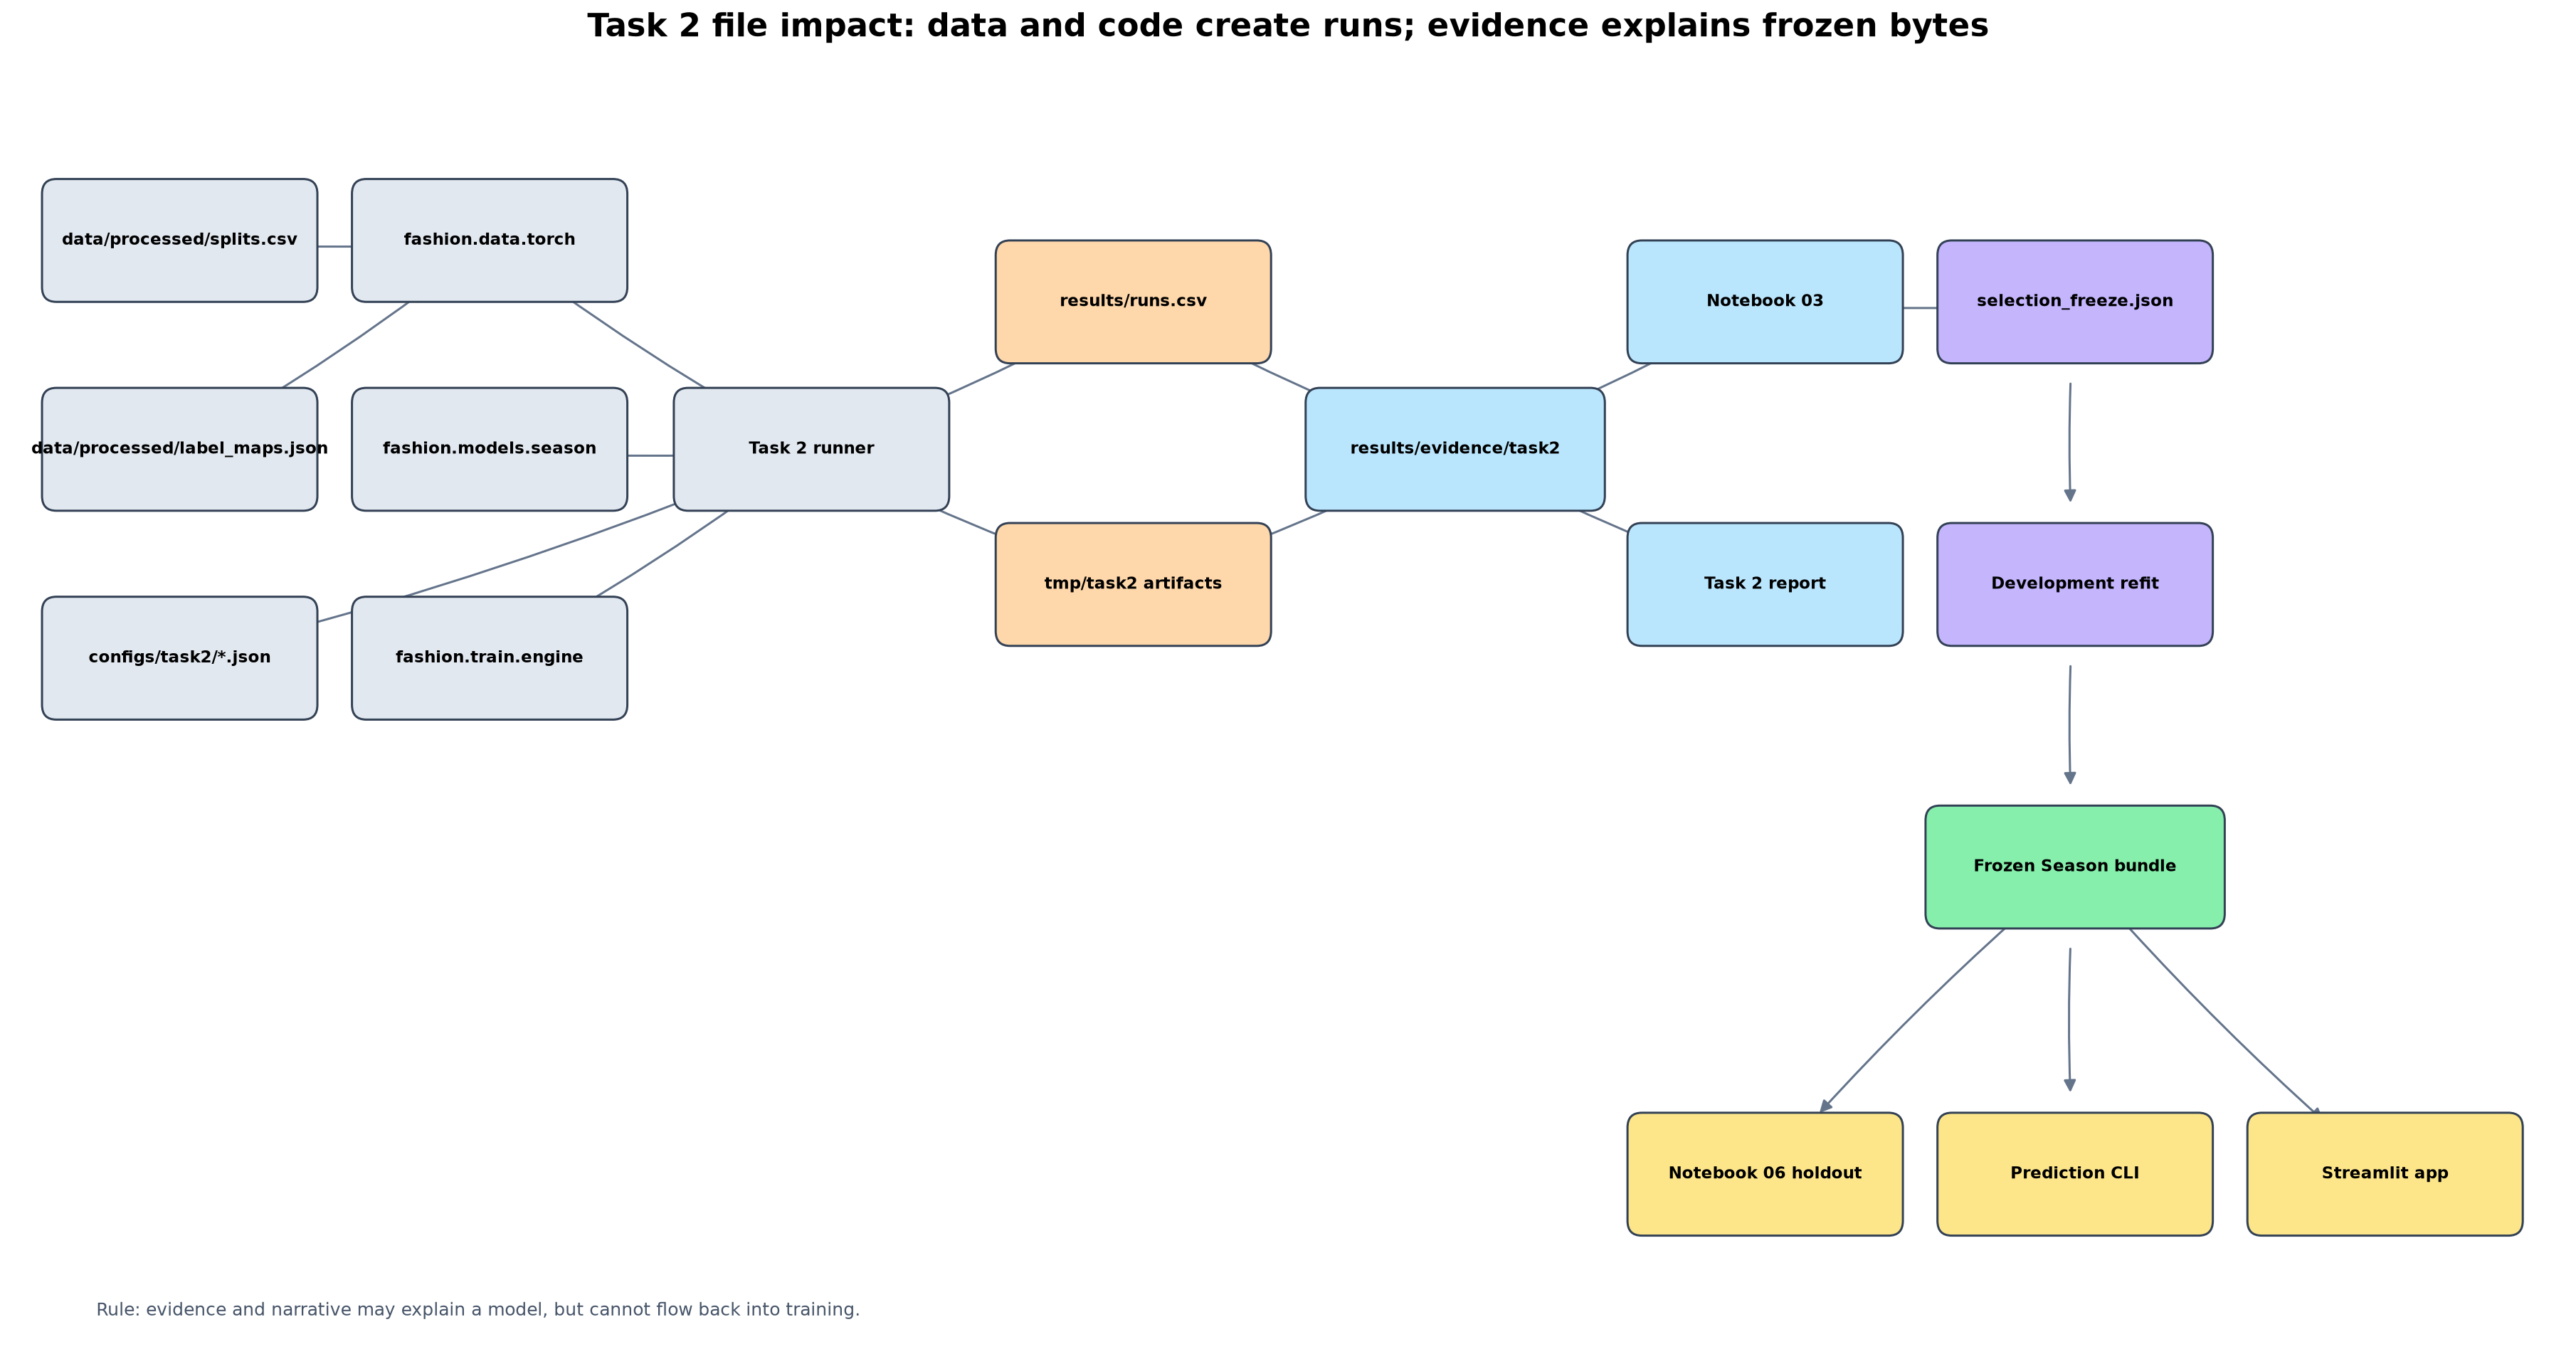

{'schema_version': '1.0.0',
 'scope': 'task2_file_impact',
 'edge_count': 18,
 'node_count': 18,
 'edges_path': 'results/evidence/task2/file_impact_edges.csv',
 'edges_sha256': '02c3e15f9cd0ec0e0c8710fb0994a61d060ccf73ed1865b36d3ba595aa23fe87',
 'figure_path': 'results/figures/task2/file_impact_flow.png',
 'figure_sha256': 'cd234563ef08e18dd60bb982078c3f76581805d755673cb010004a84c6b65dcb',
 'holdout_to_training_edges': 0,
 'deployment_input': 'Frozen Season bundle',
 'manifest_path': 'C:\\Users\\Khoai\\RMIT\\Machine_Learning\\Machine Learning at RMIT\\MLA2\\results\\evidence\\task2\\file_impact_manifest.json',
 'manifest_sha256': 'f0841ca00b5d7f333e7992dc08f81497a42df64193f2c3120a275217046e1fc9'}

In [4]:
from IPython.display import Image, display

from fashion.config import ROOT
from fashion.task2.evidence import build_task2_evidence

file_impact_manifest = build_task2_evidence()
display(Image(filename=str(ROOT / file_impact_manifest["figure_path"])))
file_impact_manifest

> **Interpretation:** **Result —** the PNG makes the one-way Task 2 lifecycle visible in Jupyter and exported HTML. **Meaning —** the selection freeze comes before development refit, while Notebook 06, the prediction CLI, and the app all read the same frozen bytes and manifest. **Decision —** use this flow when checking whether a future edit invalidates training, evidence only, or deployment. **Limitation —** arrows show allowed file impact, not runtime order or measured performance. **Trace —** `results/figures/task2/file_impact_flow.png` with its SHA-256 recorded in `file_impact_manifest.json`.

## 2. Data and EDA handoff

Reproduce only the Task 2 facts needed from Notebook 01. These are data facts, not model results.

### 2.1 Load the development task frame

Task 2 uses teacher images and excludes only rows with a truly blank Season label.

In [5]:
from fashion.data.dataset import get_samples, load_splits

splits = load_splits()
development = get_samples(splits, partition="development")
season_development = get_samples(development, target=TASK2_TARGET).reset_index(drop=True)
protected = splits["partition"].isin(["holdout", "quarantine"])
visible_protected_labels = splits.loc[protected, TASK2_TARGET].astype(str).str.strip().ne("").sum()
visible_protected_masks = splits.loc[protected, SEASON_MASK].astype(bool).sum()

assert len(development) == 32_773
assert len(season_development) == 32_753
assert len(development) - len(season_development) == 20
assert not season_development["partition"].isin(["holdout", "quarantine"]).any()
assert visible_protected_labels == visible_protected_masks == 0

task2_data_audit = pd.DataFrame(
    [
        {"check": "development rows", "value": len(development)},
        {"check": "valid Season rows", "value": len(season_development)},
        {"check": "masked Season rows", "value": len(development) - len(season_development)},
        {"check": "visible protected Season labels", "value": int(visible_protected_labels)},
        {"check": "protected rows in modelling frame", "value": 0},
    ]
)
display(task2_data_audit)

,check,value
0,development rows,32773
1,valid Season rows,32753
2,masked Season rows,20
3,visible protected Season labels,0
4,protected rows in modelling frame,0


> **Interpretation to write after running:** Confirm the counts against Notebook 01. If any value differs, stop and explain the mismatch before modelling.

### 2.2 Audit class balance, folds, and EDA evidence

This topic needs separate numeric and visual evidence, so it is divided into two subsubsections.

#### 2.2.1 Reproduce class and fold statistics

The numeric audit checks the exact EDA facts that drive imbalance and validation choices.

In [6]:
from fashion.train.artifacts import atomic_write_csv

season_counts = season_development[TASK2_TARGET].value_counts().reindex(SEASON_LABELS)
expected_counts = pd.Series(
    {"Fall": 8_928, "Spring": 1_329, "Summer": 16_235, "Winter": 6_261}
)
pd.testing.assert_series_equal(season_counts, expected_counts, check_names=False)
fold_support = (
    pd.crosstab(season_development[TASK2_TARGET], season_development["cv_fold"])
    .reindex(index=SEASON_LABELS, columns=range(5), fill_value=0)
)
assert fold_support.gt(0).all().all()
imbalance_ratio = float(season_counts.max() / season_counts.min())
eda_handoff = pd.DataFrame(
    {
        "class": SEASON_LABELS,
        "development_products": season_counts.to_numpy(),
        "share_percent": (season_counts / season_counts.sum() * 100).to_numpy(),
        **{f"fold_{fold}_validation_products": fold_support[fold].to_numpy() for fold in range(5)},
    }
)
eda_handoff["largest_to_smallest_ratio"] = imbalance_ratio
atomic_write_csv(TASK2_EVIDENCE_DIR / "eda_handoff.csv", eda_handoff)
display(
    eda_handoff.style.format(
        {"share_percent": "{:.2f}", "largest_to_smallest_ratio": "{:.2f}"}
    )
)

,class,development_products,share_percent,fold_0_validation_products,fold_1_validation_products,fold_2_validation_products,fold_3_validation_products,fold_4_validation_products,largest_to_smallest_ratio
0,Fall,8928,27.26,1786,1786,1786,1785,1785,12.22
1,Spring,1329,4.06,266,265,265,267,266,12.22
2,Summer,16235,49.57,3246,3247,3246,3248,3248,12.22
3,Winter,6261,19.12,1252,1253,1253,1250,1253,12.22


> **Interpretation to write after running:** Explain why accuracy favours Summer and why Spring needs equal weight in evaluation.

#### 2.2.2 Display the saved shortcut and transform evidence

The visual handoff keeps Notebook 03 tied to the acquisition, compression, shortcut, and transform risks found in Notebook 01.

'acquisition shortcut'

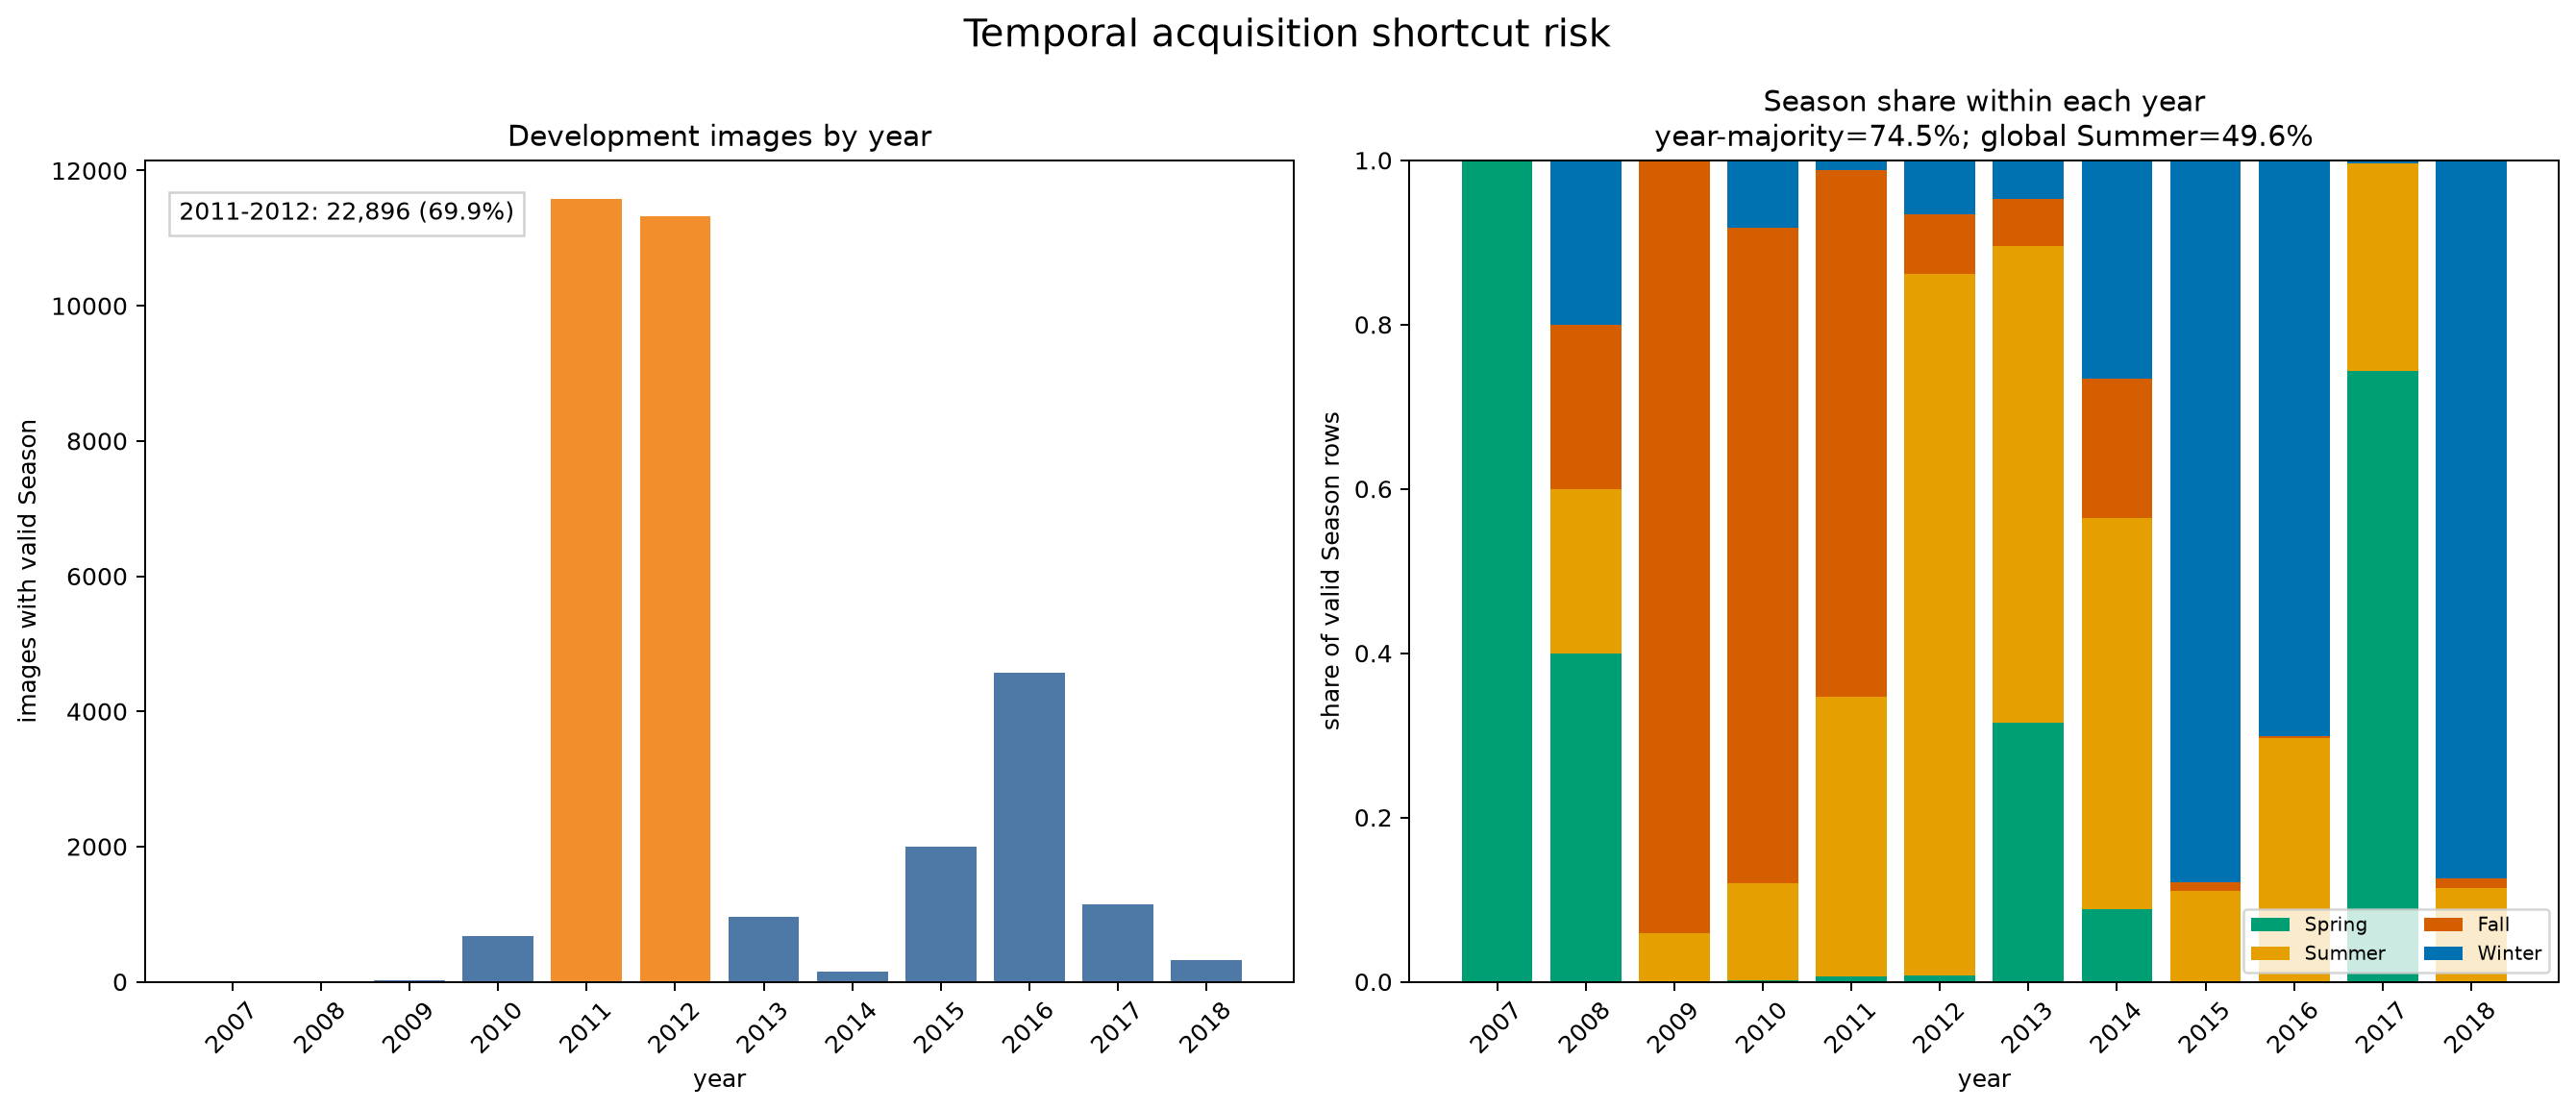

'file-size shortcut'

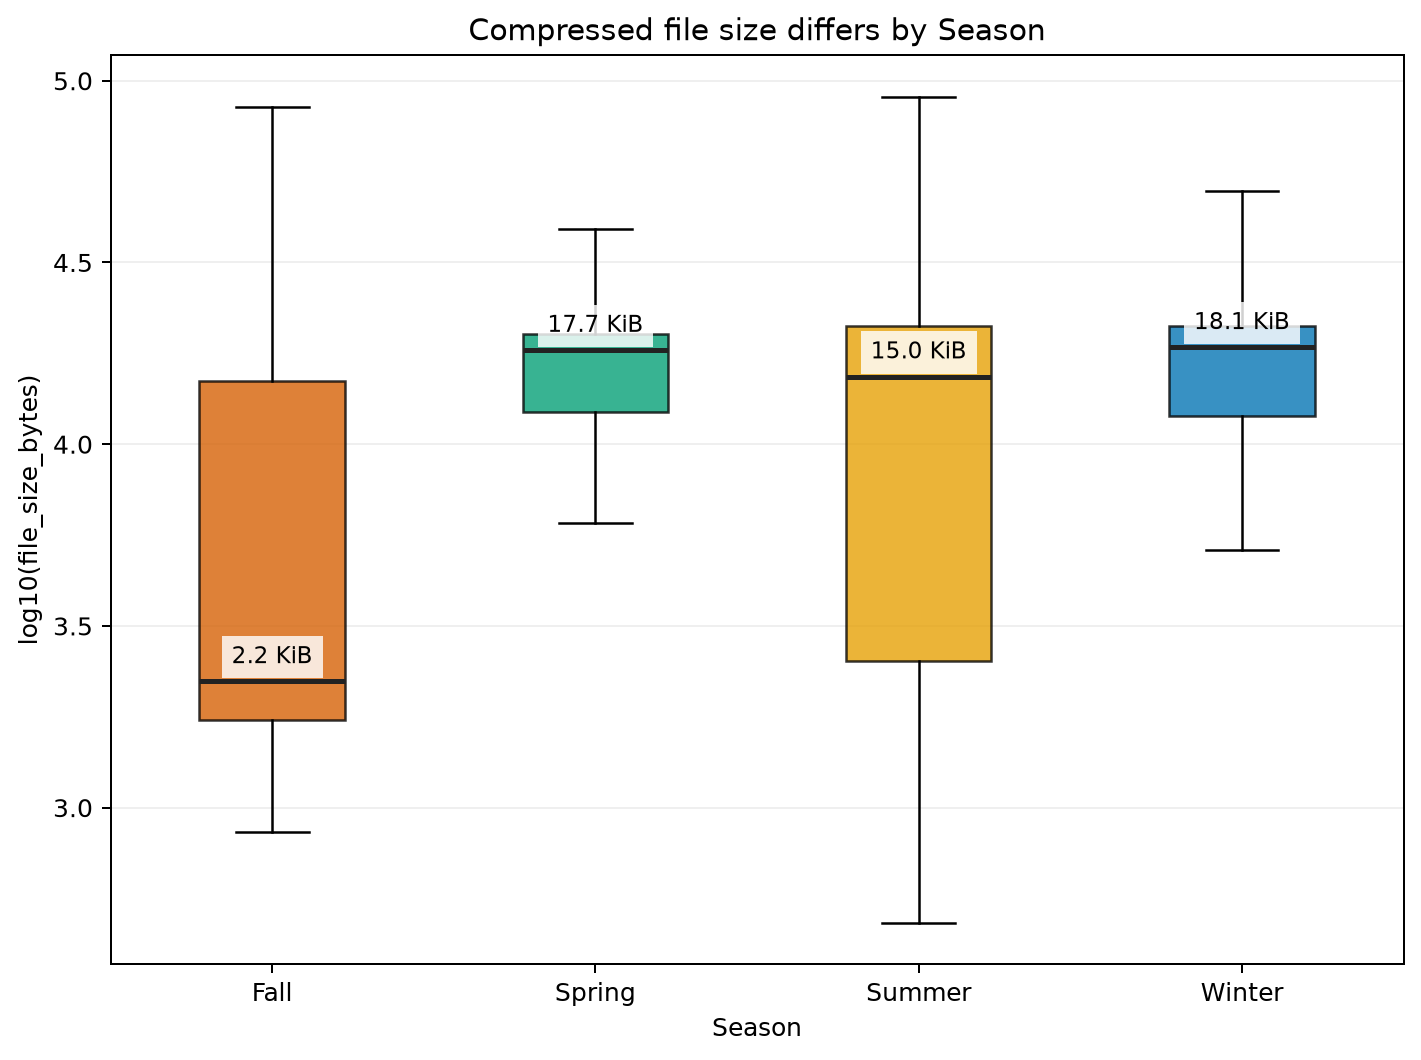

'ArticleType shortcut'

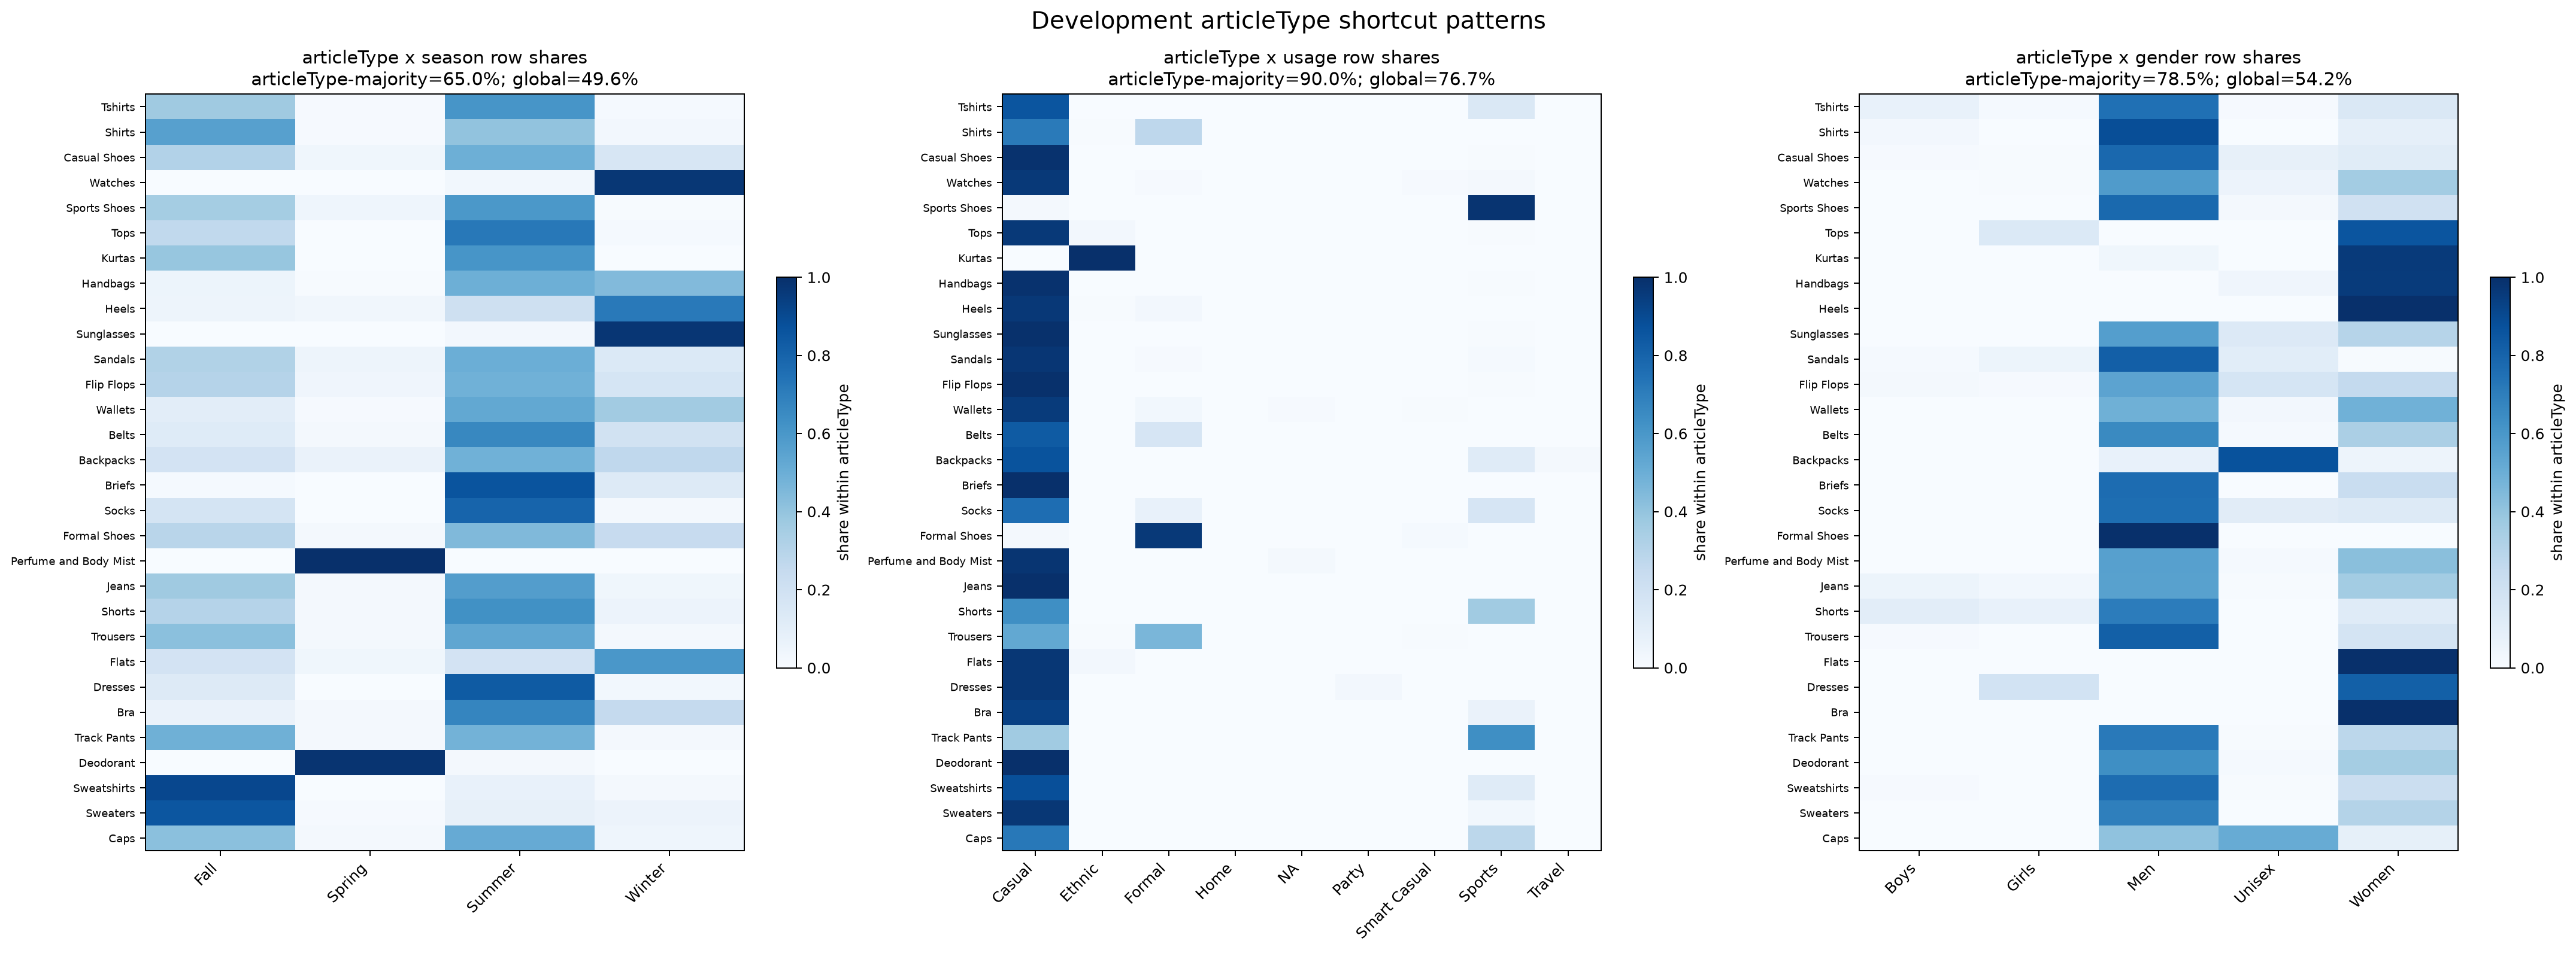

'transform risk'

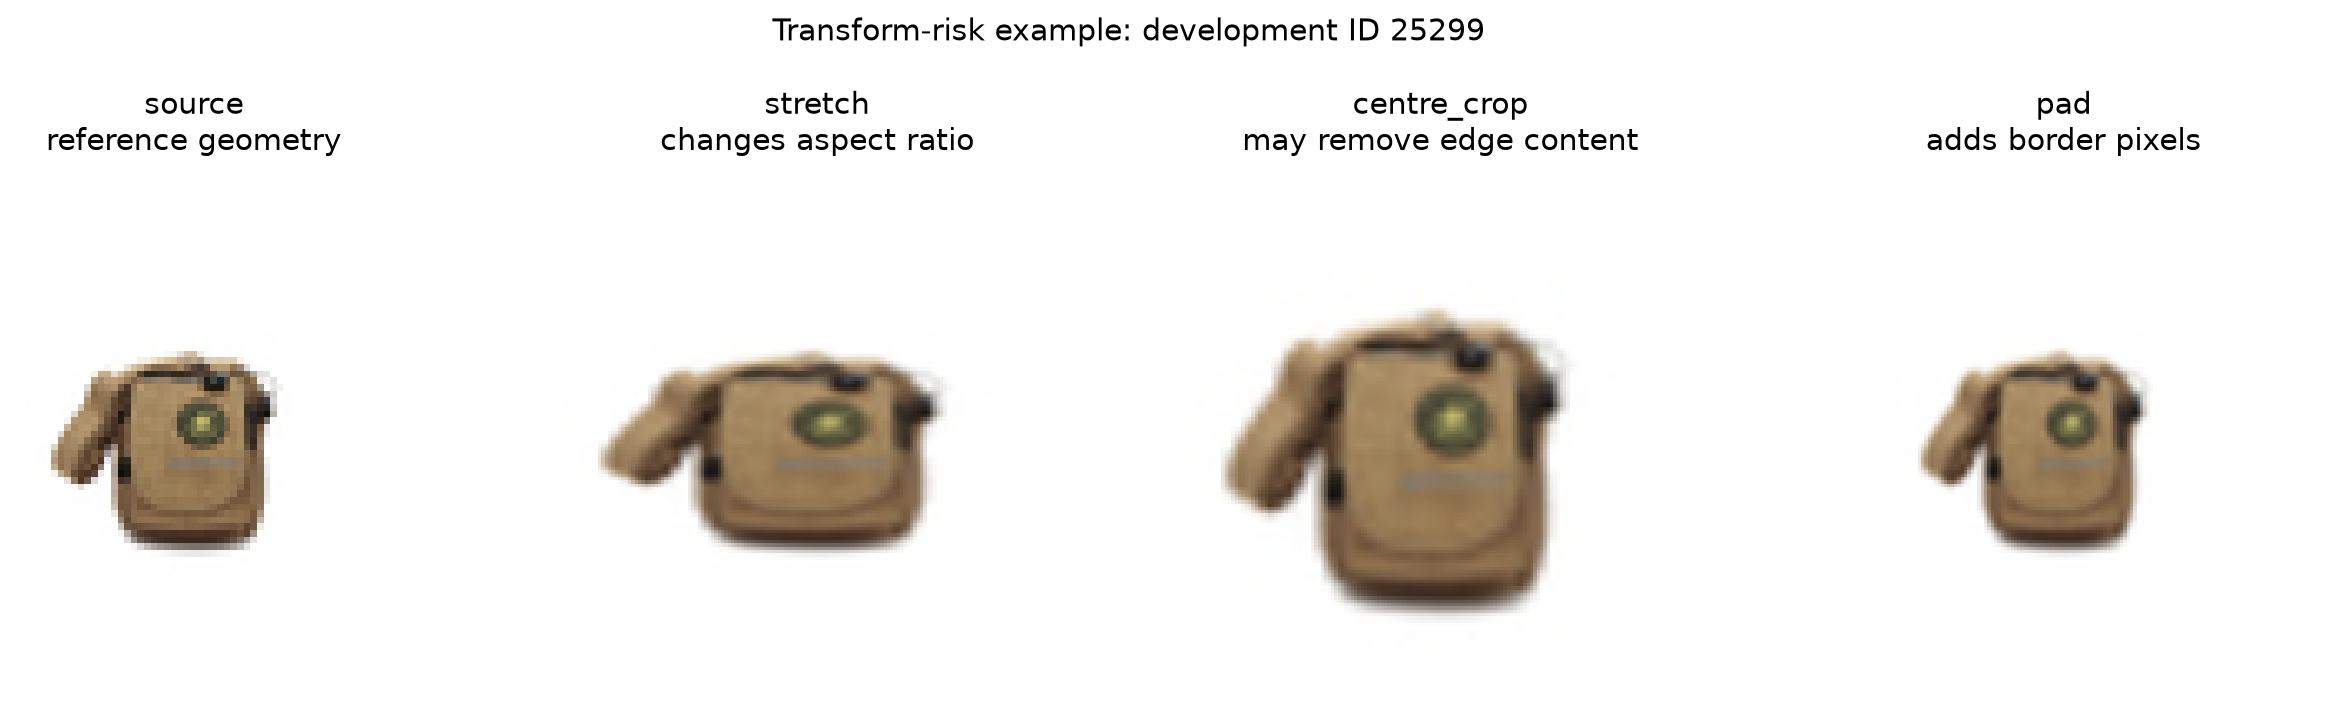

,evidence,path,sha256,claim_boundary
0,acquisition shortcut,results/figures/data_preparation/acquisition_s...,6275b416101b809abddf465c40fbb7ad7cb5eaa13f8061...,development-only description; not model accura...
1,file-size shortcut,results/figures/data_preparation/season_file_s...,c45e6763d560b62d430ac40b11255e4908ce01105f2c4c...,development-only description; not model accura...
2,ArticleType shortcut,results/figures/data_preparation/shortcut_risk...,ec200dc8cd94257a747528628fc49bf498a7c6b50282e3...,development-only description; not model accura...
3,transform risk,results/figures/data_preparation/transform_ris...,c5b984b59a846558ef0549381116a52658046d8c763000...,development-only description; not model accura...


In [7]:
from IPython.display import Image, display

from fashion.config import DATA_PREPARATION_FIGURE_DIR
from fashion.data.hashing import compute_sha256

eda_figure_paths = {
    "acquisition shortcut": DATA_PREPARATION_FIGURE_DIR / "acquisition_shortcut_risk.png",
    "file-size shortcut": DATA_PREPARATION_FIGURE_DIR / "season_file_size_shortcut.png",
    "ArticleType shortcut": DATA_PREPARATION_FIGURE_DIR / "shortcut_risk_heatmaps.png",
    "transform risk": DATA_PREPARATION_FIGURE_DIR / "transform_risk.png",
}
eda_figure_registry = pd.DataFrame(
    [
        {
            "evidence": name,
            "path": path.relative_to(ROOT).as_posix(),
            "sha256": compute_sha256(path),
            "claim_boundary": "development-only description; not model accuracy or causality",
        }
        for name, path in eda_figure_paths.items()
        if path.is_file()
    ]
)
assert len(eda_figure_registry) == len(eda_figure_paths)
atomic_write_csv(TASK2_EVIDENCE_DIR / "eda_figure_registry.csv", eda_figure_registry)
for name, path in eda_figure_paths.items():
    display(name, Image(filename=str(path)))
display(eda_figure_registry)

> **Interpretation to write after running:** State the hypotheses suggested by each figure. Keep year and file size as diagnostic slices, not inputs.

## 3. Development-validation protocol

Use all five canonical folds and create one out-of-fold prediction per valid product.

### 3.1 Build the five canonical fold views

Every candidate must see exactly the same training and validation rows.

In [8]:
from fashion.data.dataset import iter_cv_folds

fold_frames = {}
fold_rows = []
for fold, training_all, validation_all in iter_cv_folds(splits):
    training = get_samples(training_all, target=TASK2_TARGET).reset_index(drop=True)
    validation = get_samples(validation_all, target=TASK2_TARGET).reset_index(drop=True)
    family_overlap = set(training["product_family_group"]) & set(validation["product_family_group"])
    assert not family_overlap
    assert set(training[TASK2_TARGET]) == set(validation[TASK2_TARGET]) == set(SEASON_LABELS)
    fold_frames[fold] = {"training": training, "validation": validation}
    fold_rows.append(
        {
            "validation_fold": fold,
            "training_products": len(training),
            "validation_products": len(validation),
            "training_families": training["product_family_group"].nunique(),
            "validation_families": validation["product_family_group"].nunique(),
            "training_classes": training[TASK2_TARGET].nunique(),
            "validation_classes": validation[TASK2_TARGET].nunique(),
            "family_crossings": len(family_overlap),
        }
    )
fold_handoff = pd.DataFrame(fold_rows)
assert len(fold_handoff) == 5
assert fold_handoff["validation_products"].sum() == len(season_development)
atomic_write_csv(TASK2_EVIDENCE_DIR / "fold_handoff.csv", fold_handoff)
display(fold_handoff)

,validation_fold,training_products,validation_products,training_families,validation_families,training_classes,validation_classes,family_crossings
0,0,26203,6550,18324,4561,4,4,0
1,1,26202,6551,18297,4588,4,4,0
2,2,26203,6550,18311,4574,4,4,0
3,3,26203,6550,18288,4597,4,4,0
4,4,26201,6552,18320,4565,4,4,0


> **Interpretation to write after running:** State that all-five-fold CV was chosen for stable comparison and that no best-looking fold will be selected.

### 3.2 Freeze the OOF coverage contract

Pooled evidence is valid only when each product is predicted outside its training data exactly once.

In [9]:
from fashion.train.artifacts import canonical_sha256

expected_oof_index = season_development[
    ["id", "cv_fold", TASK2_TARGET, "product_family_group"]
].copy()
protected_ids = set(splits.loc[protected, "id"].astype(int))
assert expected_oof_index["id"].is_unique
assert not (set(expected_oof_index["id"].astype(int)) & protected_ids)
assert set(expected_oof_index[TASK2_TARGET]) == set(SEASON_LABELS)

oof_probability_columns = [f"prob_{label}" for label in SEASON_LABELS]
oof_contract = {
    "schema_version": "1.0.0",
    "expected_row_count": len(expected_oof_index),
    "expected_unique_ids": len(expected_oof_index),
    "expected_id_sha256": canonical_sha256(sorted(expected_oof_index["id"].astype(int))),
    "required_columns": ["id", "fold", "y_true", "y_pred", *oof_probability_columns],
    "labels": list(SEASON_LABELS),
    "probability_rule": "finite values in [0,1], four columns present, each row sums to one",
    "coverage_rule": (
        "each valid development ID appears exactly once; "
        "protected IDs appear zero times"
    ),
    "validator": "fashion.train.metrics.validate_oof",
}
atomic_write_json(TASK2_EVIDENCE_DIR / "oof_contract.json", oof_contract)
display(pd.Series(oof_contract, name="OOF contract").to_frame())

,OOF contract
schema_version,1.0.0
expected_row_count,32753
expected_unique_ids,32753
expected_id_sha256,6f8540aff2511b2d63e23bea6d5aad24060cbbf3f352d4...
required_columns,"[id, fold, y_true, y_pred, prob_Fall, prob_Spr..."
labels,"[Fall, Spring, Summer, Winter]"
probability_rule,"finite values in [0,1], four columns present, ..."
coverage_rule,each valid development ID appears exactly once...
validator,fashion.train.metrics.validate_oof


> **Interpretation to write after running:** Explain why pooled OOF predictions are the fair unit for model comparison.

### 3.3 Freeze metrics and selection rules

Metrics must be declared before candidate results are visible.

In [10]:
metric_contract = {
    "schema_version": "1.0.0",
    "primary_metric": "pooled five-fold OOF macro-F1",
    "labels": list(SEASON_LABELS),
    "zero_division": 0,
    "secondary_metrics": [
        "fold macro-F1 mean and standard deviation",
        "per-class precision, recall, F1, and support",
        "balanced accuracy and accuracy",
        "count and row-normalised confusion matrices",
        "NLL, multiclass Brier score, ECE, and risk-coverage",
        "model size, parameter count, latency, RAM, and VRAM",
    ],
    "uncertainty": "10,000 paired bootstrap samples grouped by product_family_group",
    "near_tie_macro_f1_points": 0.5,
    "near_tie_requires_ci_to_contain_zero": True,
    "smaller_model_robustness_tolerance_points": 1.0,
    "winner_rule": (
        "quality first; then robustness, calibration, and deployment cost; "
        "never accuracy alone"
    ),
}
atomic_write_json(TASK2_EVIDENCE_DIR / "metric_contract.json", metric_contract)
display(pd.Series(metric_contract, name="Metric contract").to_frame())

,Metric contract
schema_version,1.0.0
primary_metric,pooled five-fold OOF macro-F1
labels,"[Fall, Spring, Summer, Winter]"
zero_division,0
secondary_metrics,"[fold macro-F1 mean and standard deviation, pe..."
uncertainty,"10,000 paired bootstrap samples grouped by pro..."
near_tie_macro_f1_points,0.5
near_tie_requires_ci_to_contain_zero,True
smaller_model_robustness_tolerance_points,1.0
winner_rule,"quality first; then robustness, calibration, a..."


> **Interpretation to write after running:** Explain how macro-F1 gives Spring the same voting weight as Summer and how secondary metrics expose different failure types.

## 4. Preprocessing and leakage controls

Fit every learned image value inside the current training folds and keep diagnostic metadata out of the model input.

### 4.1 Fit and inspect the fold-specific image pipeline

Aspect ratio and training-only statistics protect the small 60 x 80 images from distortion and leakage.

,value
validation_fold,0
training_products,26203
validation_products,6550
id_overlap,0
labels,"[Fall, Spring, Summer, Winter]"
train_transform_id,a0-7dba8a62f166046d
validation_transform_id,none-a5c77e91d532150f
stats,"{'validation_fold': 0, 'image_size': (80, 60),..."
batch_shape,"(8, 3, 80, 60)"


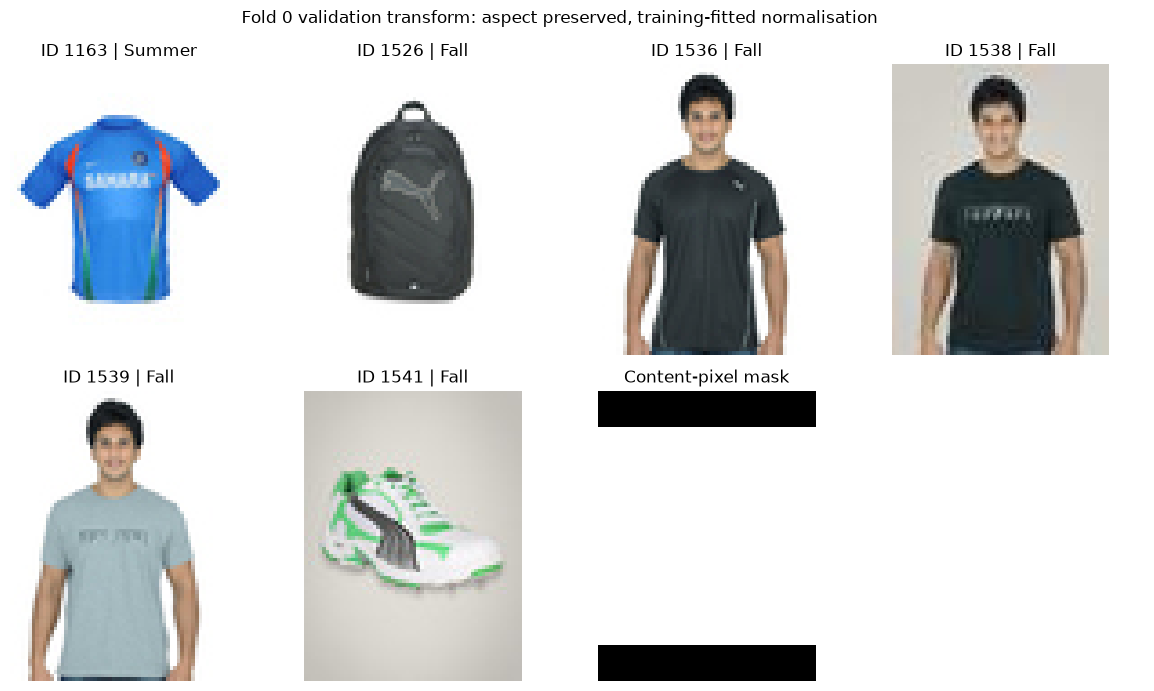

In [11]:
import io

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image as PILImage

from fashion.data.images import transform_image_with_mask
from fashion.data.torch import build_task_loaders
from fashion.train.artifacts import atomic_write_bytes

fold0_loaders = build_task_loaders(
    validation_fold=0,
    image_size=(80, 60),
    batch_size=8,
    validation_batch_size=8,
    target=TASK2_TARGET,
    augmentation="a0",
    seed=RANDOM_SEED,
    num_workers=0,
)
validation_batch = next(iter(fold0_loaders.validation))
mean = torch.tensor(fold0_loaders.stats.mean).view(1, 3, 1, 1)
std = torch.tensor(fold0_loaders.stats.std).view(1, 3, 1, 1)
display_images = (validation_batch["image"] * std + mean).clamp(0, 1)

validation_frame = fold_frames[0]["validation"]
nonstandard_aspect = validation_frame.loc[
    ~np.isclose(validation_frame["width"] / validation_frame["height"], 60 / 80)
]
assert not nonstandard_aspect.empty
first_row = nonstandard_aspect.iloc[0]
with PILImage.open(ROOT / first_row["path"]) as source:
    _, first_content_mask = transform_image_with_mask(source, image_size=(80, 60))
assert first_content_mask.any() and (~first_content_mask).any()

figure, axes = plt.subplots(2, 4, figsize=(12, 7))
for axis, image, target, item_id in zip(
    axes.flat[:6],
    display_images[:6],
    validation_batch["target"][:6],
    validation_batch["id"][:6],
    strict=True,
):
    axis.imshow(np.moveaxis(image.numpy(), 0, -1))
    axis.set_title(f"ID {int(item_id)} | {fold0_loaders.labels[int(target)]}")
    axis.axis("off")
axes.flat[6].imshow(first_content_mask, cmap="gray", vmin=0, vmax=1)
axes.flat[6].set_title("Content-pixel mask")
axes.flat[6].axis("off")
axes.flat[7].axis("off")
figure.suptitle("Fold 0 validation transform: aspect preserved, training-fitted normalisation")
figure.tight_layout()
preprocessing_figure_path = TASK2_FIGURE_DIR / "fold0_preprocessing_audit.png"
buffer = io.BytesIO()
figure.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
atomic_write_bytes(preprocessing_figure_path, buffer.getvalue())
preprocessing_summary = {
    **fold0_loaders.audit(),
    "batch_shape": tuple(validation_batch["image"].shape),
}
display(pd.Series(preprocessing_summary).to_frame("value"))

> **Interpretation to write after running:** Confirm that product shape is preserved. Explain any unusual colour or padding behaviour visible in the batch.

### 4.2 Declare the controlled transform comparison

P0/P1 and A0/A1 answer whether upscaling and mild colour change help without changing the model budget.

In [12]:
from fashion.data.torch import ImageTransformSpec

transform_rows = []
for config_id, image_size, augmentation, gate, eligibility in (
    ("P0_A0", (80, 60), "a0", "input-size", "always"),
    ("P1_A0", (128, 96), "a0", "input-size", "always"),
    ("P0_A1", (80, 60), "a1", "augmentation", "only if P0_A0 wins size gate"),
    ("P1_A1", (128, 96), "a1", "augmentation", "only if P1_A0 wins size gate"),
):
    spec = ImageTransformSpec(image_size=image_size, augmentation=augmentation)
    transform_rows.append(
        {
            "config_id": config_id,
            "gate": gate,
            "image_size": str(image_size),
            "augmentation": augmentation,
            "transform_id": spec.transform_id,
            "model_family": "resnet18_small_stem",
            "seed": RANDOM_SEED,
            "folds": "0,1,2,3,4",
            "screen_epochs": 8,
            "eligibility": eligibility,
        }
    )
transform_matrix = pd.DataFrame(transform_rows)
assert transform_matrix[["model_family", "seed", "folds", "screen_epochs"]].nunique().eq(1).all()
atomic_write_csv(TASK2_EVIDENCE_DIR / "transform_matrix.csv", transform_matrix)
display(transform_matrix)

,config_id,gate,image_size,augmentation,transform_id,model_family,seed,folds,screen_epochs,eligibility
0,P0_A0,input-size,"(80, 60)",a0,a0-7dba8a62f166046d,resnet18_small_stem,2753,"0,1,2,3,4",8,always
1,P1_A0,input-size,"(128, 96)",a0,a0-a8878a801aa0d46e,resnet18_small_stem,2753,"0,1,2,3,4",8,always
2,P0_A1,augmentation,"(80, 60)",a1,a1-fe8cc596054e42b2,resnet18_small_stem,2753,"0,1,2,3,4",8,only if P0_A0 wins size gate
3,P1_A1,augmentation,"(128, 96)",a1,a1-f127f22d8b93e7f0,resnet18_small_stem,2753,"0,1,2,3,4",8,only if P1_A0 wins size gate


> **Interpretation to write after running:** Explain which visual question each comparison answers. Do not select a transform until the controlled results exist.

### 4.3 Run the leakage and transform audit

Year, file size, and true ArticleType can define later slices but must never enter the inference tensor.

In [13]:
import inspect

from fashion.models.season import SeasonModelSpec, assert_final_model, build_season_model

audit_model = build_season_model(SeasonModelSpec(family="smallcnn"))
model_boundary = assert_final_model(audit_model)
dataset_keys = set(fold0_loaders.validation.dataset[0])
first_validation = fold0_loaders.validation.dataset[0]["image"]
second_validation = fold0_loaders.validation.dataset[0]["image"]
forward_inputs = list(inspect.signature(audit_model.forward).parameters)
forbidden_inputs = {"year", "file_size_bytes", "articleType", "season", "cv_fold", "partition"}

leakage_checks = {
    "dataset exposes only id, image, and encoded target": dataset_keys == {"id", "image", "target"},
    "model forward accepts images only": forward_inputs == ["images"],
    "forbidden metadata absent from model inputs": not (dataset_keys & forbidden_inputs),
    "validation transform is deterministic": torch.equal(first_validation, second_validation),
    "normalisation fitted on fold-0 training IDs": fold0_loaders.stats.validation_fold == 0,
    "training and validation IDs do not overlap": not (
        set(fold0_loaders.training_ids) & set(fold0_loaders.validation_ids)
    ),
    "protected labels remain sealed": visible_protected_labels == visible_protected_masks == 0,
    "audit model is scratch and final-eligible": (
        model_boundary["training_origin"] == "scratch"
        and model_boundary["final_eligible"]
    ),
}
assert all(leakage_checks.values())
leakage_audit = {
    "schema_version": "1.0.0",
    "validation_fold": 0,
    "checks": leakage_checks,
    "forbidden_inference_fields": sorted(forbidden_inputs),
    "model_boundary": model_boundary,
}
atomic_write_json(TASK2_EVIDENCE_DIR / "leakage_audit.json", leakage_audit)
display(pd.DataFrame(leakage_checks.items(), columns=["check", "passed"]))

,check,passed
0,"dataset exposes only id, image, and encoded ta...",True
1,model forward accepts images only,True
2,forbidden metadata absent from model inputs,True
3,validation transform is deterministic,True
4,normalisation fitted on fold-0 training IDs,True
5,training and validation IDs do not overlap,True
6,protected labels remain sealed,True
7,audit model is scratch and final-eligible,True


> **Interpretation to write after running:** State exactly which metadata is retained only for post-prediction analysis and why that does not leak into training.

## 5. Baselines

Establish simple comparison anchors before interpreting deep models.

### 5.1 B0 training-fold majority baseline

B0 verifies fold handling and shows what the 49.57% Summer majority can achieve.

,experiment_id,OOF products,accuracy,balanced_accuracy,macro_f1,Spring_f1,run_ids
0,b0-majority,32753,0.49568,0.25,0.165704,0.0,b0-majority-f0-s2753-8200c51534e3 | b0-majorit...


,metric,fold_mean,fold_sd,fold_min,fold_max,pooled_value
5,macro_f1,0.165704,0.000029,0.16568,0.165748,0.165704


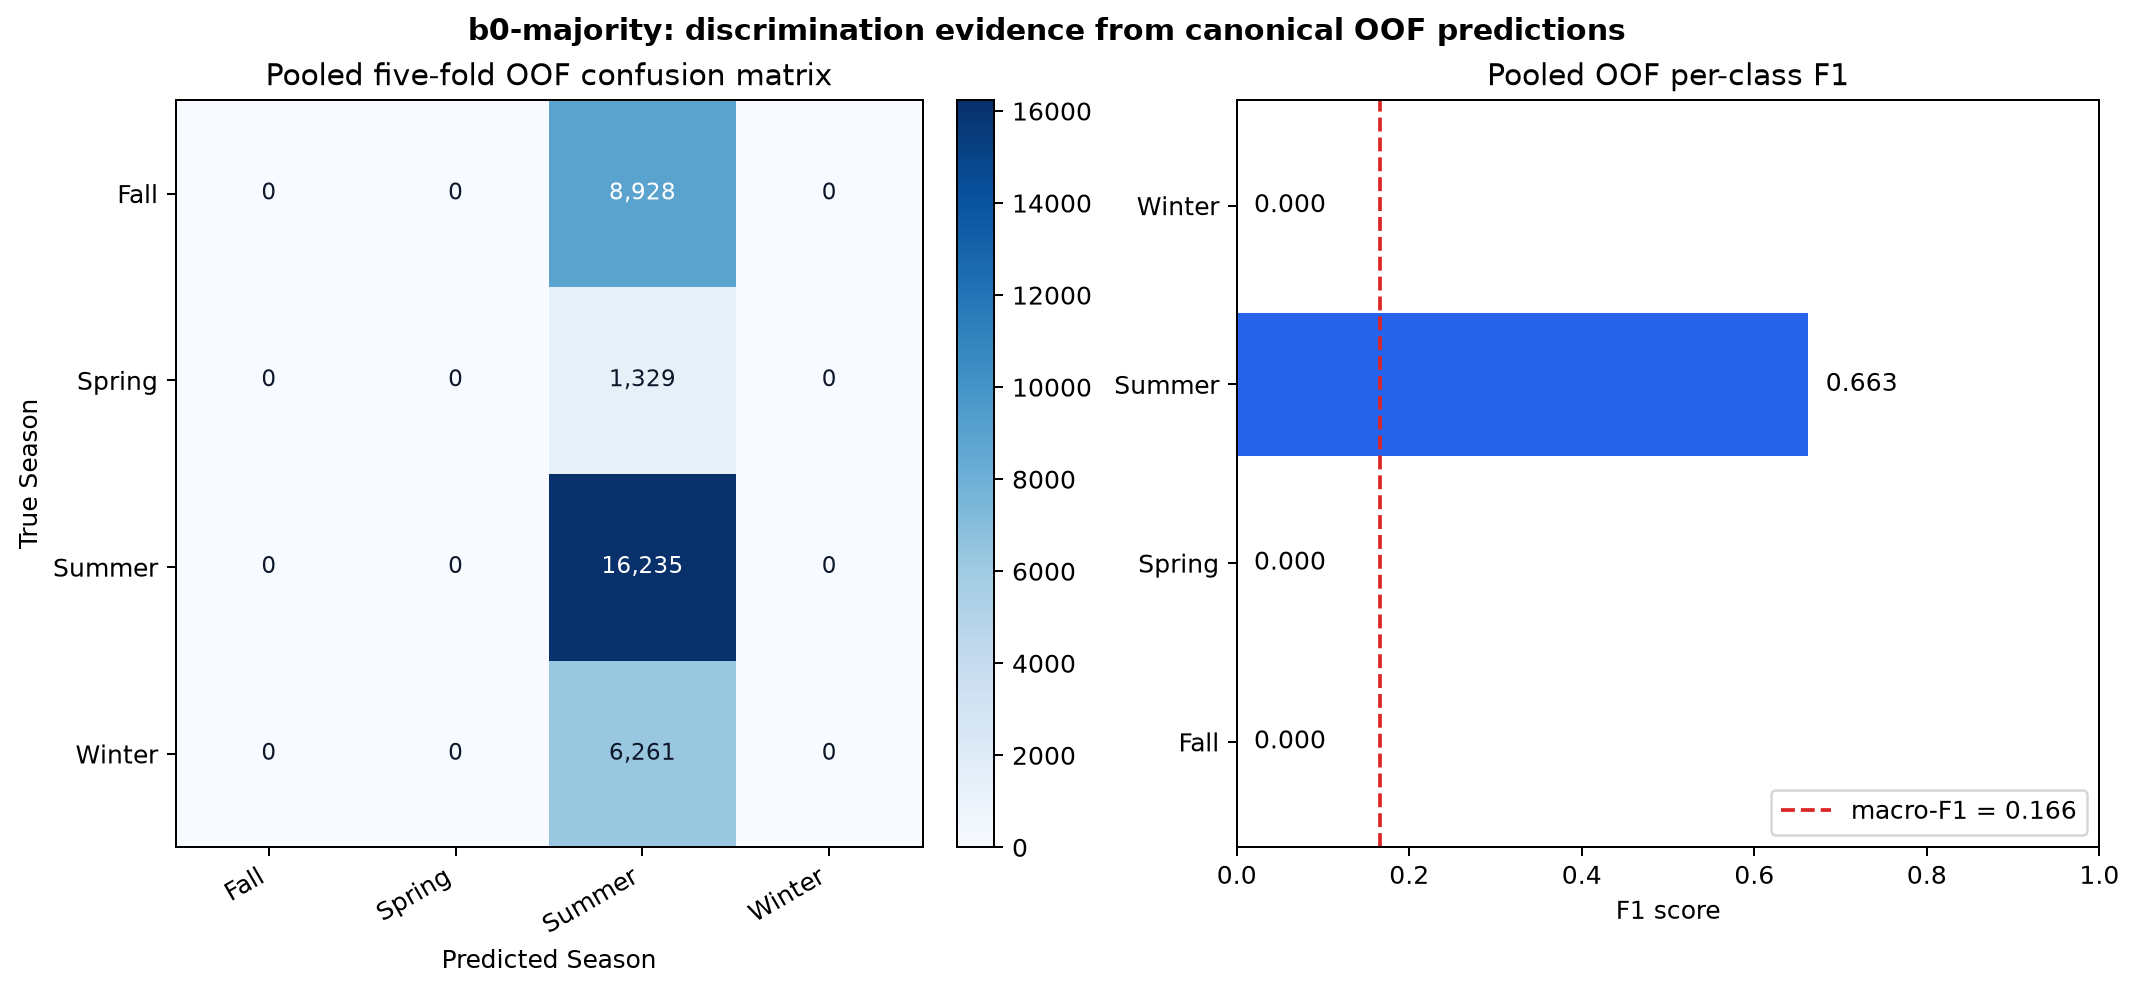

In [14]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.experiments import run_or_load_experiment

b0_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "b0_majority.json",
    mode="run_or_load",
)
b0_manifest = build_experiment_evidence(
    b0_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=(
        "Each validation product receives empirical Season priors fitted only on "
        "the other four training folds; these are valid probabilistic baseline "
        "outputs, not image-conditioned confidence."
    ),
    calibration_claim_allowed=True,
    evidence_directory=TASK2_EVIDENCE_DIR / "b0_majority",
    figure_directory=TASK2_FIGURE_DIR,
)
assert b0_manifest["coverage"]["row_count"] == len(season_development)
assert b0_manifest["coverage"]["protected_id_count"] == 0
assert len(b0_manifest["run_ids"]) == len(set(b0_manifest["run_ids"])) == 5

with (ROOT / b0_manifest["artifacts"]["pooled_metrics"]["path"]).open(
    encoding="utf-8"
) as handle:
    b0_pooled_metrics = json.load(handle)
b0_fold_summary = pd.read_csv(
    ROOT / b0_manifest["artifacts"]["fold_summary"]["path"]
)
b0_scorecard = pd.DataFrame(
    [{
        "experiment_id": b0_manifest["experiment_id"],
        "OOF products": b0_pooled_metrics["n_samples"],
        "accuracy": b0_pooled_metrics["accuracy"],
        "balanced_accuracy": b0_pooled_metrics["balanced_accuracy"],
        "macro_f1": b0_pooled_metrics["macro_f1"],
        "Spring_f1": b0_pooled_metrics["per_class"]["Spring"]["f1"],
        "run_ids": " | ".join(b0_manifest["run_ids"]),
    }]
)
display(b0_scorecard)
display(b0_fold_summary.loc[b0_fold_summary["metric"].eq("macro_f1")])
display(Image(filename=str(ROOT / b0_manifest["artifacts"]["figure"]["path"])))

> **Interpretation:** **Result —** B0 covered all 32,753 valid development products once, with no protected IDs. It reached 49.568% accuracy but only `0.165704` pooled macro-F1 and `0.250000` balanced accuracy. It predicted Summer for every product: Summer F1 was `0.662815`, while Fall, Spring, and Winter F1 were all zero. Fold macro-F1 SD was only `0.000029`. **Meaning —** the apparently reasonable accuracy comes only from the 49.57% Summer class share; it does not show useful four-class discrimination. **Decision —** every learned model must beat `0.165704` macro-F1 and must recover minority-class recall, especially Spring, before it is useful. **Limitation —** B0 deliberately ignores every image. Its near-zero ECE means the training-fold prior matches the pooled class frequency; it does not mean the classifier distinguishes seasons. **Trace —** `results/evidence/task2/b0_majority/manifest.json`; runs `b0-majority-f0-s2753-8200c51534e3`, `b0-majority-f1-s2753-7c378e67d9e6`, `b0-majority-f2-s2753-e50abeab2421`, `b0-majority-f3-s2753-b2fb197c26c1`, and `b0-majority-f4-s2753-b068532dab0a`.

### 5.2 B1 HOG plus HSV linear-SVM baseline

B1 tests whether hand-designed shape and colour features already carry useful Season signal.

,experiment_id,OOF products,accuracy,balanced_accuracy,macro_f1,macro_f1_gain_over_B0,Spring_precision,Spring_recall,Spring_f1,five_fold_runtime_minutes,linear_parameters
0,b1-hog-hsv-svm,32753,0.657405,0.620671,0.609561,0.443857,0.423098,0.573363,0.486901,36.143584,7916


,metric,fold_mean,fold_sd,fold_min,fold_max,pooled_value
5,macro_f1,0.609586,0.006962,0.602874,0.621388,0.609561


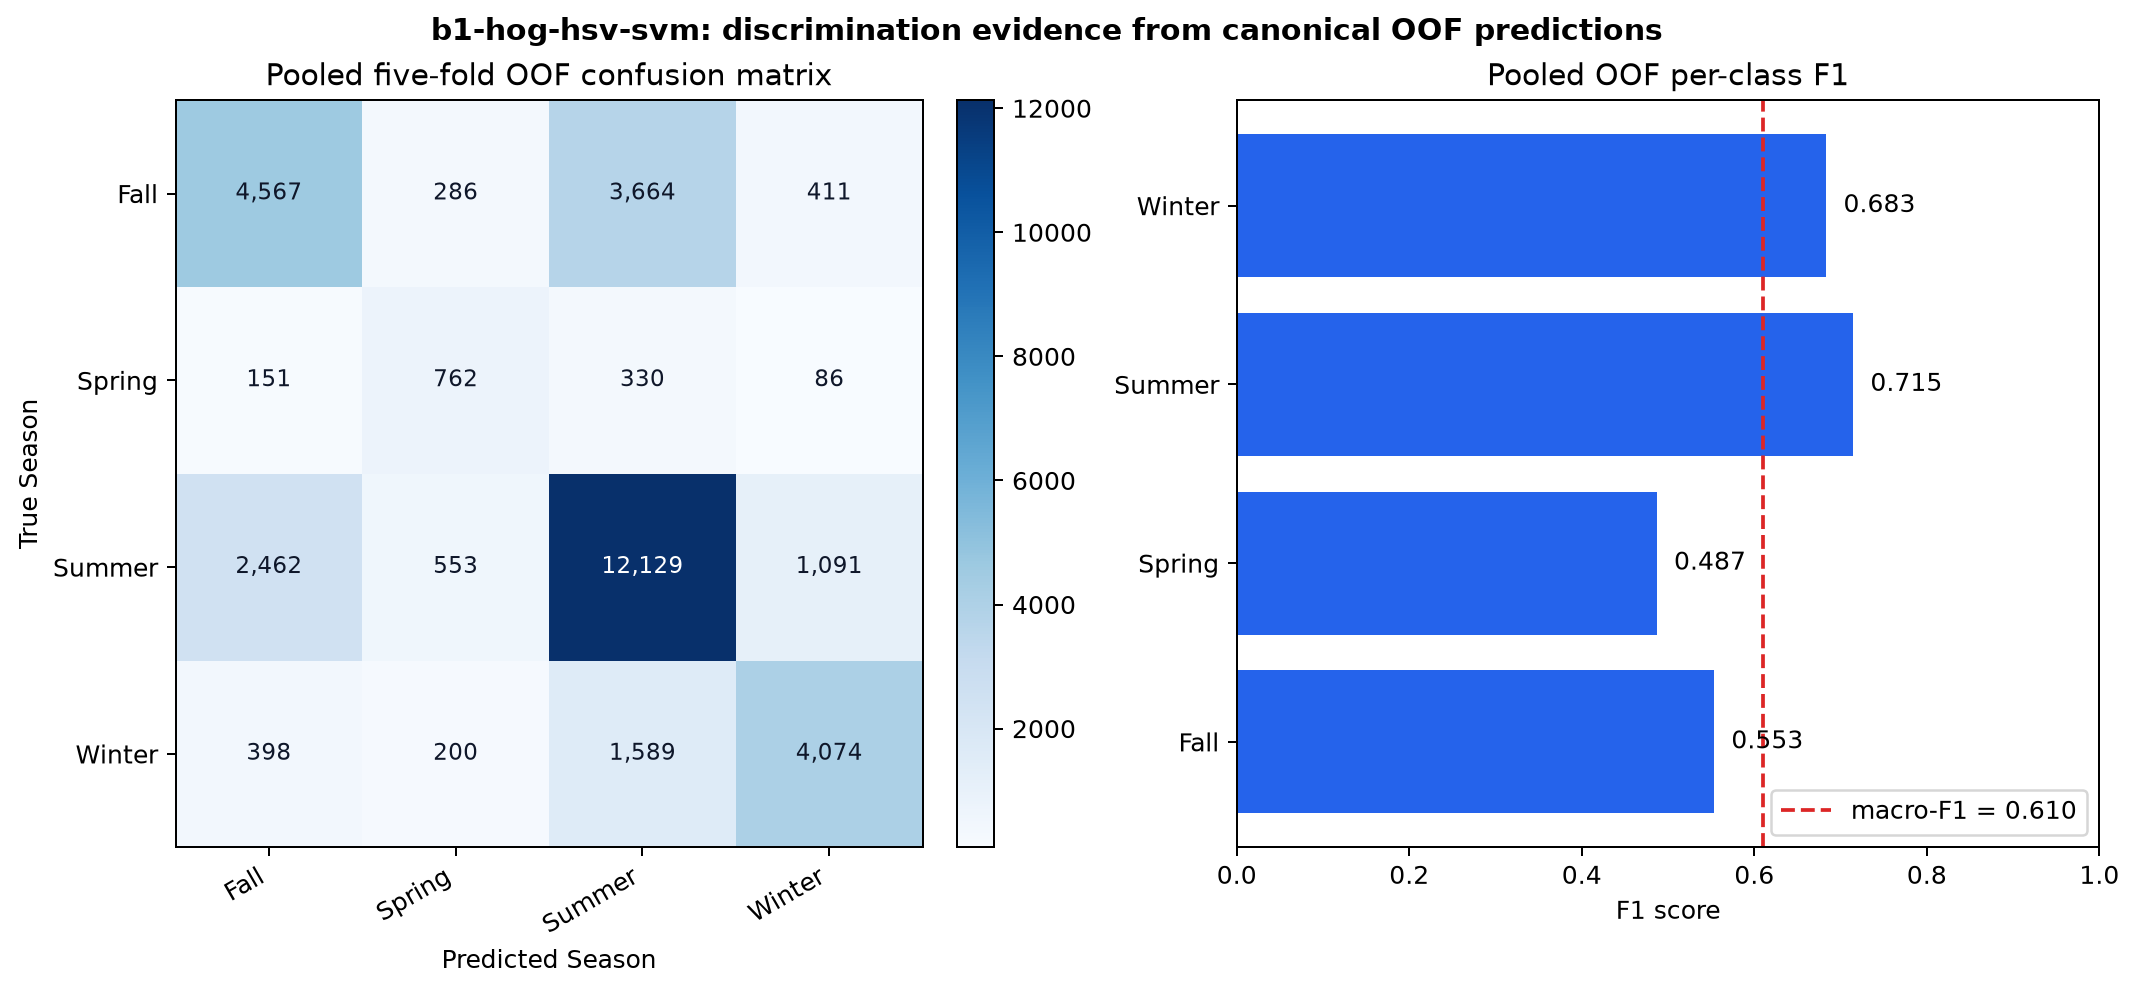

In [15]:
b1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "b1_hog_hsv_svm.json",
    mode="run_or_load",
)
b1_manifest = build_experiment_evidence(
    b1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=(
        "LinearSVC decision scores are transformed with row-wise softmax only "
        "to satisfy a common OOF storage schema. They are not calibrated "
        "probabilities, so B1 NLL, Brier, and ECE are descriptive diagnostics "
        "only and cannot support calibration claims."
    ),
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "b1_hog_hsv_svm",
    figure_directory=TASK2_FIGURE_DIR,
)
assert b1_manifest["coverage"]["row_count"] == len(season_development)
assert b1_manifest["coverage"]["protected_id_count"] == 0
assert not b1_manifest["calibration_claim_allowed"]
assert len(b1_manifest["run_ids"]) == len(set(b1_manifest["run_ids"])) == 5

with (ROOT / b1_manifest["artifacts"]["pooled_metrics"]["path"]).open(
    encoding="utf-8"
) as handle:
    b1_pooled_metrics = json.load(handle)
b1_fold_summary = pd.read_csv(
    ROOT / b1_manifest["artifacts"]["fold_summary"]["path"]
)
b1_registry = pd.read_csv(
    ROOT / b1_manifest["artifacts"]["registry_snapshot"]["path"]
)
b1_scorecard = pd.DataFrame(
    [{
        "experiment_id": b1_manifest["experiment_id"],
        "OOF products": b1_pooled_metrics["n_samples"],
        "accuracy": b1_pooled_metrics["accuracy"],
        "balanced_accuracy": b1_pooled_metrics["balanced_accuracy"],
        "macro_f1": b1_pooled_metrics["macro_f1"],
        "macro_f1_gain_over_B0": (
            b1_pooled_metrics["macro_f1"] - b0_pooled_metrics["macro_f1"]
        ),
        "Spring_precision": b1_pooled_metrics["per_class"]["Spring"]["precision"],
        "Spring_recall": b1_pooled_metrics["per_class"]["Spring"]["recall"],
        "Spring_f1": b1_pooled_metrics["per_class"]["Spring"]["f1"],
        "five_fold_runtime_minutes": b1_registry["runtime_seconds"].sum() / 60,
        "linear_parameters": int(b1_registry["parameter_count"].iloc[0]),
    }]
)
display(b1_scorecard)
display(b1_fold_summary.loc[b1_fold_summary["metric"].eq("macro_f1")])
display(Image(filename=str(ROOT / b1_manifest["artifacts"]["figure"]["path"])))

> **Interpretation:** **Result —** B1 covered all 32,753 valid development products once with no protected IDs. It reached `0.609561` pooled macro-F1, `0.657405` accuracy, and `0.620671` balanced accuracy: a `0.443857` absolute macro-F1 gain over B0. Spring precision, recall, and F1 were `0.423098`, `0.573363`, and `0.486901`; pooled F1 was `0.553375` for Fall, `0.714584` for Summer, and `0.683385` for Winter. Fold macro-F1 SD was `0.006962`. **Meaning —** deterministic shape and colour features contain substantial Season signal; B1 is a serious baseline, not a token comparison. Its main errors still send 3,664 Fall and 1,589 Winter products to Summer, while Spring remains the weakest class by F1. **Decision —** C1/C2/C3 must beat `0.609561` macro-F1 or provide a clear robustness, efficiency, or minority-class advantage. **Limitation —** the softmax-transformed LinearSVC decision scores are not calibrated probabilities, so B1 NLL, Brier, and ECE cannot support calibration claims. Five CPU folds took `36.14` minutes in total, and HOG/HSV may exploit catalogue style rather than causal season cues. **Trace —** `results/evidence/task2/b1_hog_hsv_svm/manifest.json`; runs `b1-hog-hsv-svm-f0-s2753-b23d1eafe35f`, `b1-hog-hsv-svm-f1-s2753-5735c51cc237`, `b1-hog-hsv-svm-f2-s2753-3f214f6a2bd4`, `b1-hog-hsv-svm-f3-s2753-83fd8ce0b942`, and `b1-hog-hsv-svm-f4-s2753-45b2e5123926`.

## 6. Scratch model families

Define three different deep-learning capacities and prove that the submitted candidates start from random weights.

### 6.1 Define the scratch model factories

Each architecture is a separate implementation unit and therefore receives its own subsubsection and code cell.

#### 6.1.1 C1 four-block SmallCNN

C1 is the simple deep baseline and makes capacity and failure analysis easy to explain.

In [16]:
from fashion.models.season import (
    SeasonModelSpec,
    assert_final_model,
    build_season_model,
)

smallcnn = build_season_model(
    SeasonModelSpec(family="smallcnn", num_classes=len(SEASON_LABELS))
)
smallcnn_boundary = assert_final_model(smallcnn)
with torch.inference_mode():
    smallcnn_logits = smallcnn(torch.zeros(2, 3, 80, 60))
assert tuple(smallcnn_logits.shape) == (2, len(SEASON_LABELS))
display(pd.DataFrame([{**smallcnn_boundary, "output_shape": tuple(smallcnn_logits.shape)}]))

,class,training_origin,benchmark_only,final_eligible,weights,output_shape
0,SmallSeasonCNN,scratch,False,True,None,"(2, 4)"


> **Interpretation to write after running:** Explain why C1 is a useful capacity baseline and what it may miss on small catalogue images.

#### 6.1.2 C2 ResNet18 with a small-image stem

C2 tests residual learning without discarding small-image detail in the first layers.

In [17]:
from torch import nn

resnet18_small_stem = build_season_model(
    SeasonModelSpec(family="resnet18_small_stem", num_classes=len(SEASON_LABELS))
)
resnet_boundary = assert_final_model(resnet18_small_stem)
stem = resnet18_small_stem.backbone.conv1
assert stem.kernel_size == (3, 3) and stem.stride == (1, 1)
assert isinstance(resnet18_small_stem.backbone.maxpool, nn.Identity)
with torch.inference_mode():
    resnet_logits = resnet18_small_stem(torch.zeros(2, 3, 80, 60))
assert tuple(resnet_logits.shape) == (2, len(SEASON_LABELS))
resnet_summary = {
    **resnet_boundary,
    "stem": "3x3, stride 1, no max-pool",
    "output_shape": tuple(resnet_logits.shape),
}
display(pd.DataFrame([resnet_summary]))

,class,training_origin,benchmark_only,final_eligible,weights,stem,output_shape
0,ScratchSmallStemResNet18,scratch,False,True,None,"3x3, stride 1, no max-pool","(2, 4)"


> **Interpretation to write after running:** Confirm that the shared factory calls ResNet18 with `weights=None`. Explain why the 3 x 3 stride-1 stem differs from the standard ImageNet design and how residual capacity may help.

#### 6.1.3 C3 MobileNetV3-Small

C3 tests whether a mobile architecture offers a better quality-to-latency trade-off.

In [18]:
mobilenet_v3_small = build_season_model(
    SeasonModelSpec(family="mobilenet_v3_small", num_classes=len(SEASON_LABELS))
)
mobilenet_boundary = assert_final_model(mobilenet_v3_small)
with torch.inference_mode():
    mobilenet_logits = mobilenet_v3_small(torch.zeros(2, 3, 80, 60))
assert tuple(mobilenet_logits.shape) == (2, len(SEASON_LABELS))
display(pd.DataFrame([{**mobilenet_boundary, "output_shape": tuple(mobilenet_logits.shape)}]))

,class,training_origin,benchmark_only,final_eligible,weights,output_shape
0,ScratchMobileNetV3Small,scratch,False,True,None,"(2, 4)"


> **Interpretation to write after running:** Explain the expected parameter and latency advantage and why it must be measured rather than assumed.

### 6.2 Audit shapes, parameters, and random initialisation

A forward-pass and weight-provenance audit catches architecture mistakes before GPU runs.

In [19]:
def state_dict_sha256(model):
    digest = hashlib.sha256()
    for name, tensor in sorted(model.state_dict().items()):
        values = tensor.detach().cpu().contiguous().numpy()
        digest.update(name.encode("utf-8"))
        digest.update(str(values.dtype).encode("ascii"))
        digest.update(str(values.shape).encode("ascii"))
        digest.update(values.tobytes())
    return digest.hexdigest()

model_families = {
    "C1": smallcnn,
    "C2": resnet18_small_stem,
    "C3": mobilenet_v3_small,
}
real_images = validation_batch["image"][:2]
synthetic_images = torch.zeros(2, 3, 128, 96)
model_audit_rows = []
for model_id, model in model_families.items():
    model.eval()
    with torch.inference_mode():
        real_logits = model(real_images)
        synthetic_logits = model(synthetic_images)
    assert real_logits.shape == synthetic_logits.shape == (2, len(SEASON_LABELS))
    assert torch.isfinite(real_logits).all() and torch.isfinite(synthetic_logits).all()
    boundary = assert_final_model(model)
    model_audit_rows.append(
        {
            "model_id": model_id,
            "class": type(model).__name__,
            "parameters": sum(parameter.numel() for parameter in model.parameters()),
            "trainable_parameters": sum(
                parameter.numel()
                for parameter in model.parameters()
                if parameter.requires_grad
            ),
            "initial_state_sha256": state_dict_sha256(model),
            **boundary,
            "p0_forward_pass": True,
            "p1_forward_pass": True,
        }
    )
scratch_model_audit = pd.DataFrame(model_audit_rows)
atomic_write_csv(TASK2_EVIDENCE_DIR / "scratch_model_audit.csv", scratch_model_audit)
display(scratch_model_audit)

,model_id,class,parameters,trainable_parameters,initial_state_sha256,training_origin,benchmark_only,final_eligible,weights,p0_forward_pass,p1_forward_pass
0,C1,SmallSeasonCNN,1174244,1174244,6a4b761ee246405c2cc5f642160b961b9fb459a647b7d1...,scratch,False,True,None,True,True
1,C2,ScratchSmallStemResNet18,11170884,11170884,1f01887973b739c477d19d9f08c9bc19b45a6c995776f9...,scratch,False,True,None,True,True
2,C3,ScratchMobileNetV3Small,1521956,1521956,d16f06681d4444e52241cf1b57064631be62cd53b417e7...,scratch,False,True,None,True,True


> **Interpretation to write after running:** Compare capacity and expected deployment cost. Confirm that each submitted candidate is scratch-trained.

### 6.3 Declare the pretrained benchmark boundary

A pretrained comparison is useful only when it is clearly excluded from final eligibility.

In [20]:
from fashion.models.season import (
    BenchmarkModelSpec,
    ModelBoundaryError,
    build_benchmark_model,
    model_boundary_audit,
)

standard_stem_control = build_benchmark_model(
    BenchmarkModelSpec(family="resnet18_standard_scratch", num_classes=len(SEASON_LABELS))
)
standard_control_boundary = model_boundary_audit(standard_stem_control)
try:
    assert_final_model(standard_stem_control)
except ModelBoundaryError as boundary_error:
    benchmark_rejection = str(boundary_error)
else:
    raise AssertionError("benchmark model entered the final-model boundary")

pretrained_spec = BenchmarkModelSpec(
    family="resnet18_standard_pretrained",
    num_classes=len(SEASON_LABELS),
)
pretrained_spec.validate()
benchmark_boundary = pd.DataFrame(
    [
        {
            "experiment": "P0S",
            "family": "resnet18_standard_scratch",
            "training_origin": "scratch",
            "weights": None,
            "benchmark_only": True,
            "final_eligible": False,
        },
        {
            "experiment": "P*",
            "family": pretrained_spec.family,
            "training_origin": "imagenet_pretrained",
            "weights": "ResNet18_Weights.DEFAULT",
            "benchmark_only": True,
            "final_eligible": False,
        },
    ]
)
assert benchmark_boundary["benchmark_only"].all() and not benchmark_boundary["final_eligible"].any()
benchmark_boundary["final_boundary_rejection"] = benchmark_rejection
atomic_write_csv(TASK2_EVIDENCE_DIR / "benchmark_boundary.csv", benchmark_boundary)
display(benchmark_boundary)

,experiment,family,training_origin,weights,benchmark_only,final_eligible,final_boundary_rejection
0,P0S,resnet18_standard_scratch,scratch,NaN,True,False,model is not final-eligible: benchmark_only mu...
1,P*,resnet18_standard_pretrained,imagenet_pretrained,ResNet18_Weights.DEFAULT,True,False,model is not final-eligible: benchmark_only mu...


> **Interpretation to write after running:** Explain what the pretrained gap says about data and representation learning, without selecting P* as the final model.

## 7. Training and run registry

Prove the shared engine, checkpointing, failure handling, and registry before long runs.

### 7.1 G0 tiny-batch smoke test

A tiny overfit test catches label order, image mapping, loss, and backpropagation errors cheaply.

,G0 pipeline gate
run_id,g0-pipeline-smoke-f0-s2753-5ad5ee9d433c
source,cache
passed,True
tiny_final_accuracy,1.0
tiny_loss_ratio,0.000015
integration_epochs,2
integration_macro_f1_non_comparison,0.343262
checkpoint_sha256,154dc1a91c428001b4c6c261e756311a195ddd55d76bfb...


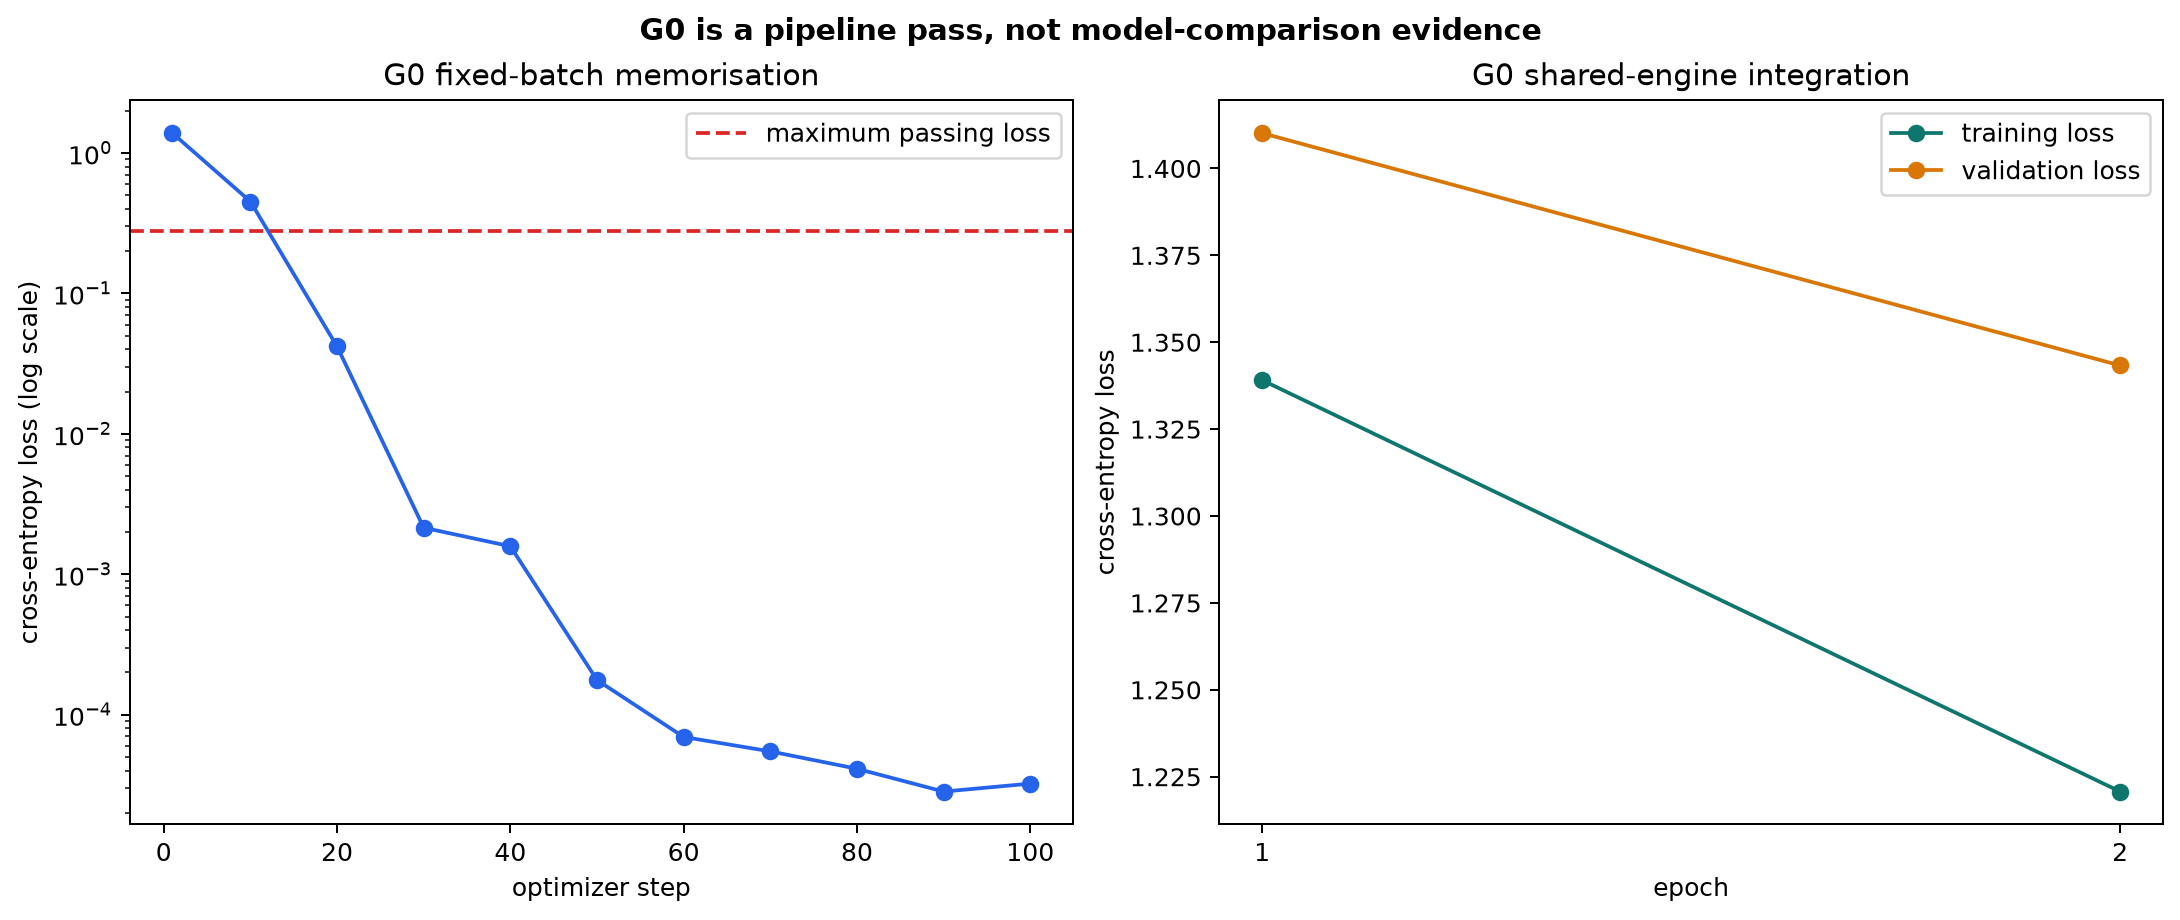

{'schema_version': '1.0.0',
 'gate': 'G0',
 'passed': True,
 'comparison_eligible': False,
 'run_id': 'g0-pipeline-smoke-f0-s2753-5ad5ee9d433c',
 'source': 'cache',
 'cache_key': {'config_sha256': '7d87f50206caf2bfd83f800dd128db56e6e9269eb513ce583e39f83ec73a12de',
  'split_sha256': 'd76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db',
  'label_map_sha256': '51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327',
  'implementation_sha256': '6346eb33ea704593ca71aa48a975aac8f0169a76a41a8a4113a9c2141f7bb2a4',
  'fold': 0,
  'seed': 2753},
 'tiny_overfit': {'products': 64,
  'steps': 100,
  'device': 'cuda',
  'initial_loss': 1.385862112045288,
  'final_loss': 2.0097653759876266e-05,
  'final_accuracy': 1.0,
  'loss_ratio': 1.4501914429434595e-05,
  'minimum_accuracy': 0.95,
  'maximum_loss_ratio': 0.2,
  'gradients_finite': True,
  'passed': True},
 'integration': {'training_products': 512,
  'validation_products': 128,
  'epochs_completed': 2,
  'best_epoch': 2,
 

In [21]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_g0_evidence
from fashion.task2.smoke import run_or_load_g0_smoke

g0_result = run_or_load_g0_smoke(
    TASK2_CONFIG_DIR / "g0_pipeline_smoke.json",
    mode="run_or_load",
)
g0_manifest = build_g0_evidence(g0_result, registry_path=RUNS_CSV)
g0_summary = {
    "run_id": g0_result.run_id,
    "source": g0_result.source,
    "passed": g0_result.passed,
    "tiny_final_accuracy": g0_result.tiny_overfit["final_accuracy"],
    "tiny_loss_ratio": g0_result.tiny_overfit["loss_ratio"],
    "integration_epochs": g0_result.integration["epochs_completed"],
    "integration_macro_f1_non_comparison": (
        g0_result.integration["best_metrics"]["macro_f1"]
    ),
    "checkpoint_sha256": g0_result.artifacts["checkpoint"],
}
display(pd.Series(g0_summary, name="G0 pipeline gate").to_frame())
display(Image(filename=str(ROOT / g0_manifest["figure_path"])))
g0_manifest

> **Interpretation:** **Result —** clean run `g0-pipeline-smoke-f0-s2753-5ad5ee9d433c` passed: the balanced 64-image batch reached 100% accuracy after 100 steps, its final loss was `0.0000145` of the initial loss, gradients stayed finite, and the 512-image integration run completed two epochs with hash-verified artifacts. **Meaning —** the loader-cache implementation change correctly invalidated the stale G0 cache; the external rerun closed the current functional gate, and this Run All reused its verified bytes. **Provenance —** the selected registry snapshot records commit `7d70e3f`, `git_dirty=false`, the current implementation hash, and `status=completed`. The earlier dirty row remains in the append-only registry but supports no claim. **Decision —** G0 unlocks the measured experiments. Its integration macro-F1 is deliberately excluded from every leaderboard. **Limitation —** G0 uses small balanced subsets and fold 0 only, so it says nothing about comparative model quality or five-fold stability. **Trace —** `results/evidence/task2/g0/manifest.json`, its one-row clean registry snapshot, and the run ID above.

### 7.2 Audit registry and checkpoint traceability

Every reported number must be traceable to configuration, split, code, and artifact hashes.

In [22]:
from fashion.config import RUNS_CSV
from fashion.train.registry import RUN_COLUMNS, RUN_STATUSES, RunRegistry

run_registry = RunRegistry(RUNS_CSV)
registry_rows = run_registry.read()
schema_matches = tuple(registry_rows.columns) == RUN_COLUMNS
unique_run_ids = not registry_rows["run_id"].duplicated().any()
known_statuses = set(registry_rows["status"]) <= RUN_STATUSES
declared_checkpoints = registry_rows.loc[registry_rows["checkpoint_path"].ne(""), "checkpoint_path"]
checkpoint_paths_exist = all((ROOT / path).is_file() for path in declared_checkpoints)
hash_columns = ["config_sha256", "split_sha256", "label_map_sha256", "implementation_sha256"]
identity_hashes_valid = registry_rows.empty or registry_rows[hash_columns].apply(
    lambda column: column.str.fullmatch(r"[0-9a-f]{64}").all()
).all()
registry_health = {
    "schema_version": "1.0.0",
    "registry_path": RUNS_CSV.relative_to(ROOT).as_posix(),
    "run_count": len(registry_rows),
    "schema_matches": bool(schema_matches),
    "unique_run_ids": bool(unique_run_ids),
    "known_statuses": bool(known_statuses),
    "identity_hashes_valid": bool(identity_hashes_valid),
    "declared_checkpoints_exist": bool(checkpoint_paths_exist),
    "status_counts": registry_rows["status"].value_counts().sort_index().to_dict(),
}
assert all(
    registry_health[key]
    for key in (
        "schema_matches",
        "unique_run_ids",
        "known_statuses",
        "identity_hashes_valid",
        "declared_checkpoints_exist",
    )
)
atomic_write_json(TASK2_EVIDENCE_DIR / "registry_health.json", registry_health)
display(pd.Series(registry_health, name="Registry health").to_frame())
display(registry_rows.tail(10))

,Registry health
schema_version,1.0.0
registry_path,results/runs.csv
run_count,36
schema_matches,True
unique_run_ids,True
known_statuses,True
identity_hashes_valid,True
declared_checkpoints_exist,True
status_counts,"{'completed': 33, 'failed': 1, 'interrupted': 2}"


,run_id,task,stage,experiment_id,model_family,benchmark_only,final_eligible,scratch,fold,seed,...,prediction_path,prediction_sha256,history_path,history_sha256,status,error_type,error_message,started_at_utc,finished_at_utc,runtime
26,g0-pipeline-smoke-f0-s2753-b921bf3b6418,task2,g0_smoke,g0-pipeline-smoke,smallcnn,false,false,true,0,2753,...,tmp/task2/runs/g0-pipeline-smoke-f0-s2753-b921...,599aaf522eed614c4b01143928d86d77b9de36c27ec10d...,tmp/task2/runs/g0-pipeline-smoke-f0-s2753-b921...,4bd063851bda4d7da49f0520d5e5c0011f8ab88879e8fb...,completed,,,2026-08-26T17:15:00Z,2026-08-26T17:15:07Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
27,g0-pipeline-smoke-f0-s2753-5ad5ee9d433c,task2,g0_smoke,g0-pipeline-smoke,smallcnn,false,false,true,0,2753,...,tmp/task2/runs/g0-pipeline-smoke-f0-s2753-5ad5...,9ed4ad7189b1dafb3cf4ca4c6d8a2e2855d53d3874f6c7...,tmp/task2/runs/g0-pipeline-smoke-f0-s2753-5ad5...,e0415ce2b97301e23868f9c6f3abfc5e9ca3b17d7a1895...,completed,,,2026-08-26T17:21:24Z,2026-08-26T17:21:32Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
28,g2-p1-c2-resnet18-f0-s2753-67217738d381,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,0,2753,...,tmp/task2/runs/g2-p1-c2-resnet18-f0-s2753-6721...,eeb5cf9d50955aa6b6684ff10accdea935d591d994833b...,tmp/task2/runs/g2-p1-c2-resnet18-f0-s2753-6721...,88fe36981de15e90cafe5ec70cb9809fe8c2064faa6b57...,completed,,,2026-08-26T17:30:19Z,2026-08-26T17:42:28Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
29,g2-p1-c2-resnet18-f1-s2753-7327d09ce2cf,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,1,2753,...,,,,,interrupted,ExternalProcessTermination,Codex training terminal exited externally befo...,2026-08-26T17:42:28Z,2026-08-26T18:05:26Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
30,g2-p1-c2-resnet18-f1-s2753-dce57b0c7883,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,1,2753,...,,,,,interrupted,ExternalProcessTermination,Windows background runner omitted the __main__...,2026-08-26T18:08:10Z,2026-08-26T18:09:24Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
31,g2-p1-c2-resnet18-f1-s2753-48ece6ab6852,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,1,2753,...,,,,,failed,RuntimeError,\n An attempt has been made to start a ...,2026-08-26T18:08:17Z,2026-08-26T18:08:18Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
32,g2-p1-c2-resnet18-f1-s2753-66a1b27539dc,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,1,2753,...,tmp/task2/runs/g2-p1-c2-resnet18-f1-s2753-66a1...,444ec37dc25d00ba38e8432645d02b2331c146ef3fbce3...,tmp/task2/runs/g2-p1-c2-resnet18-f1-s2753-66a1...,75476178bee143f87320355137994b74720f17568046ea...,completed,,,2026-08-26T18:11:27Z,2026-08-26T18:23:09Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
33,g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,2,2753,...,tmp/task2/runs/g2-p1-c2-resnet18-f2-s2753-b5a8...,f4d290d64658ecc92997fd4b4e232918559d80cadb5d12...,tmp/task2/runs/g2-p1-c2-resnet18-f2-s2753-b5a8...,555f5a78c95b3af95b6622bd805d4bf9d20bd1423b1be8...,completed,,,2026-08-26T18:23:10Z,2026-08-26T18:35:13Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
34,g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,3,2753,...,tmp/task2/runs/g2-p1-c2-resnet18-f3-s2753-8e6b...,c8817d41ff1e20a998259e4ffd07ba38c0c162781695ea...,tmp/task2/runs/g2-p1-c2-resnet18-f3-s2753-8e6b...,e882f593de9a75d8eee35f20d5ce6c4586657a9b2858d6...,completed,,,2026-08-26T18:35:14Z,2026-08-26T18:47:20Z,"{""cuda_available"":true,""cuda_runtime"":""12.6"",""..."
35,g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4,task2,g2_input_size_ablation,g2-p1-c2-resnet18,resnet18_small_stem,false,true,true,4,2753,...,tmp/task2/run

> **Interpretation to write after running:** Confirm that each future table can be regenerated from run IDs. Explain any failed run honestly.

## 8. Controlled experiment matrix

Execute broad comparisons under equal budgets, then spend extra compute only on justified finalists.

### 8.1 G1 and G3 model-family comparison

Screening and full finalist training answer different questions, so they are separated below.

#### 8.1.1 G1 equal-budget family screening

The screen decides which families deserve more compute under one fixed budget.

,rank,experiment_id,model_family,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,parameter_count,five_fold_runtime_minutes,peak_vram_mb,shortlisted,delta_vs_best_macro_f1,gain_over_b1_macro_f1
0,1,g1-c2-resnet18,resnet18_small_stem,0.7071,0.706496,0.0039,0.7384,11170884,29.21,606.4,True,0.000000,+0.0975
1,2,g1-c1-smallcnn,smallcnn,0.6999,0.699752,0.0109,0.7262,1174244,19.11,191.4,True,-0.007197,+0.0903
2,3,g1-c3-mobilenetv3,mobilenet_v3_small,0.6385,0.638336,0.0083,0.6688,1521956,16.66,74.3,False,-0.068604,+0.0289


,experiment_id,fold,run_id,source,fold_macro_f1
0,g1-c1-smallcnn,0,g1-c1-smallcnn-f0-s2753-59e9743d3899,cache,0.699749
1,g1-c1-smallcnn,1,g1-c1-smallcnn-f1-s2753-f73cfae4a798,cache,0.683056
2,g1-c1-smallcnn,2,g1-c1-smallcnn-f2-s2753-8e178abd5435,cache,0.710146
3,g1-c1-smallcnn,3,g1-c1-smallcnn-f3-s2753-bf3525f7f30f,cache,0.708893
4,g1-c1-smallcnn,4,g1-c1-smallcnn-f4-s2753-476a7394ed3e,cache,0.696914
5,g1-c2-resnet18,0,g1-c2-resnet18-f0-s2753-b91662d47026,cache,0.703758
6,g1-c2-resnet18,1,g1-c2-resnet18-f1-s2753-a4ff07c863e4,cache,0.705058
7,g1-c2-resnet18,2,g1-c2-resnet18-f2-s2753-2d6a8dffa3fe,cache,0.712810
8,g1-c2-resnet18,3,g1-c2-resnet18-f3-s2753-f2eb5f7a2dac,cache,0.707456
9,g1-c2-resnet18,4,g1-c2-resnet18-f4-s2753-2449eed2ce12,cache,0.703396


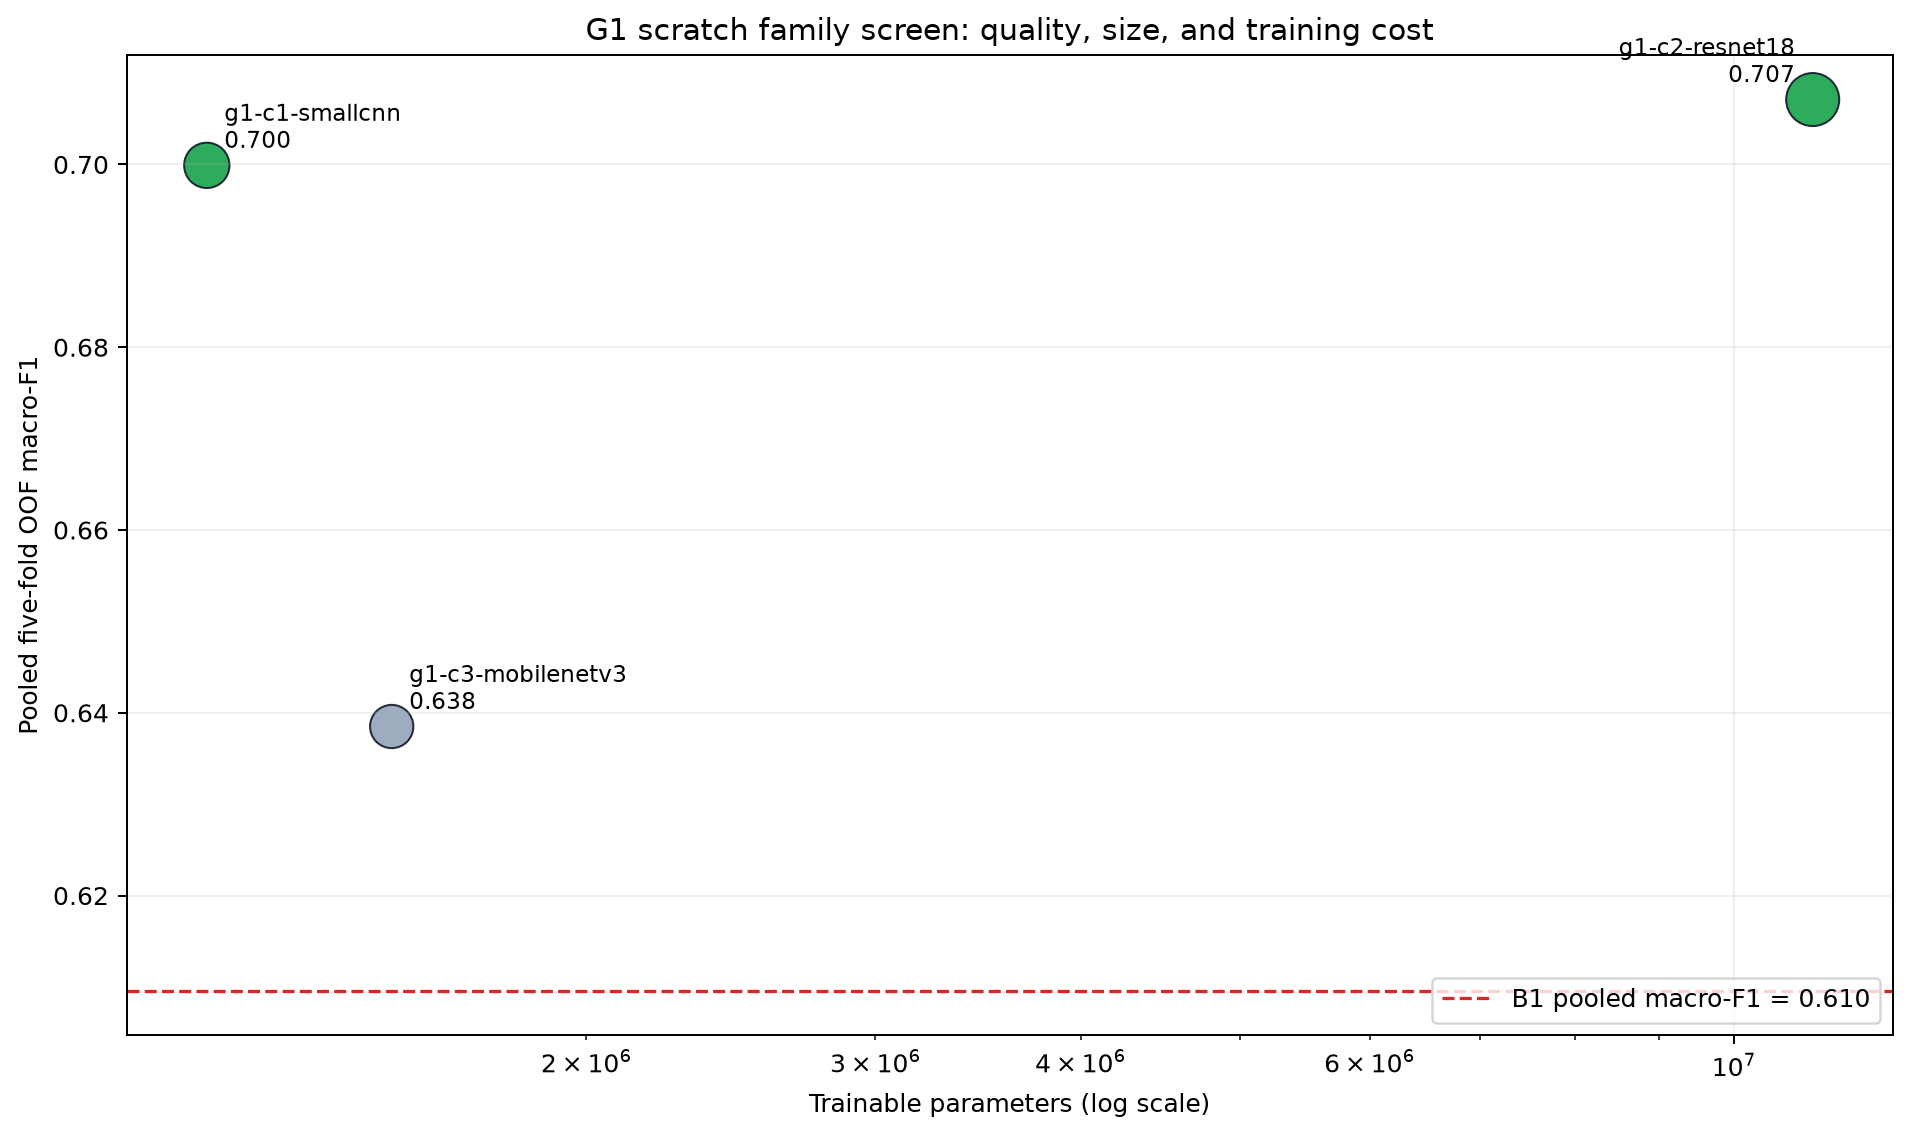

In [23]:
from fashion.task2.evidence import build_g1_family_screen_evidence

g1_specs = {
    "g1-c1-smallcnn": ("g1_c1_smallcnn.json", "g1_c1_smallcnn"),
    "g1-c2-resnet18": ("g1_c2_resnet18.json", "g1_c2_resnet18"),
    "g1-c3-mobilenetv3": ("g1_c3_mobilenetv3.json", "g1_c3_mobilenetv3"),
}
g1_probability_note = (
    "Softmax probabilities come from each fold's best validation macro-F1 "
    "checkpoint. They are uncalibrated until the dedicated cross-fitted "
    "calibration gate, so current NLL, Brier, and ECE are diagnostics only."
)
g1_manifests = {}
g1_trace_rows = []
for experiment_id, (config_name, evidence_slug) in g1_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g1_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    g1_manifests[experiment_id] = experiment_manifest
    g1_trace_rows.extend(
        {
            "experiment_id": experiment_id,
            "fold": output.fold,
            "run_id": output.run_id,
            "source": output.source,
            "fold_macro_f1": output.metrics["macro_f1"],
        }
        for output in outputs
    )

g1_screen_manifest = build_g1_family_screen_evidence(
    [TASK2_EVIDENCE_DIR / slug / "manifest.json" for _, slug in g1_specs.values()],
    reference_manifest_path=TASK2_EVIDENCE_DIR / "b1_hog_hsv_svm/manifest.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g1_family_screen",
    figure_directory=TASK2_FIGURE_DIR,
)
g1_leaderboard = pd.read_csv(
    ROOT / g1_screen_manifest["artifacts"]["leaderboard"]["path"]
)
with (ROOT / g1_screen_manifest["artifacts"]["shortlist"]["path"]).open(
    encoding="utf-8"
) as handle:
    g1_shortlist = json.load(handle)
assert g1_shortlist["selected_experiment_ids"] == [
    "g1-c2-resnet18",
    "g1-c1-smallcnn",
]
assert g1_shortlist["rejected_experiment_ids"] == ["g1-c3-mobilenetv3"]
assert len(g1_trace_rows) == 15
display(
    g1_leaderboard.style.format(
        {
            "pooled_macro_f1": "{:.4f}",
            "fold_sd_macro_f1": "{:.4f}",
            "spring_f1": "{:.4f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
            "gain_over_b1_macro_f1": "{:+.4f}",
        }
    )
)
display(pd.DataFrame(g1_trace_rows).sort_values(["experiment_id", "fold"]))
display(
    Image(filename=str(ROOT / g1_screen_manifest["artifacts"]["figure"]["path"]))
)

> **Interpretation:** **Result:** all three scratch families produced exactly 32,753 pooled OOF predictions with zero protected IDs under the same P0/A0, seed 2753, five-fold, eight-epoch protocol. C2 ResNet18 ranked first (`0.707099` pooled macro-F1; fold SD `0.003872`; Spring F1 `0.738433`), followed by C1 SmallCNN (`0.699902`; SD `0.010936`; Spring F1 `0.726168`) and C3 MobileNetV3-Small (`0.638495`; SD `0.008339`; Spring F1 `0.668816`). All beat B1 (`0.609561`), by `0.097538`, `0.090341`, and `0.028934`, respectively. **Meaning:** residual capacity gave C2 the best and most stable screen score, but its `11,170,884` parameters and `29.21` training minutes bought only `0.007197` macro-F1 over C1, which used `1,174,244` parameters and `19.11` minutes. C3 was smallest in measured VRAM (`74.3` MB) and fastest (`16.66` minutes), but trailed C2 by `0.068604`; efficiency did not offset that quality loss. **Decision:** shortlist C2 as the quality leader and C1 as the compact efficiency challenger. Reject C3 from further tuning. Run P0/P1 and A0/A1 on C2, then compare C2 and C1 under the same full G3 budget. **Limitation:** this is one seed, one transform, and an eight-epoch screen; probabilities are not yet calibrated, so the screen cannot freeze the final winner. **Trace:** `results/evidence/task2/g1_family_screen/manifest.json` links the 15 immutable run IDs shown above. C1 runs: `g1-c1-smallcnn-f0-s2753-59e9743d3899`, `g1-c1-smallcnn-f1-s2753-f73cfae4a798`, `g1-c1-smallcnn-f2-s2753-8e178abd5435`, `g1-c1-smallcnn-f3-s2753-bf3525f7f30f`, `g1-c1-smallcnn-f4-s2753-476a7394ed3e`; C2 runs: `g1-c2-resnet18-f0-s2753-b91662d47026`, `g1-c2-resnet18-f1-s2753-a4ff07c863e4`, `g1-c2-resnet18-f2-s2753-2d6a8dffa3fe`, `g1-c2-resnet18-f3-s2753-f2eb5f7a2dac`, `g1-c2-resnet18-f4-s2753-2449eed2ce12`; C3 runs: `g1-c3-mobilenetv3-f0-s2753-9e07fe2a3158`, `g1-c3-mobilenetv3-f1-s2753-7f3f65f2ebbb`, `g1-c3-mobilenetv3-f2-s2753-35dc3f614c96`, `g1-c3-mobilenetv3-f3-s2753-a90ee2f892fb`, and `g1-c3-mobilenetv3-f4-s2753-bf6c9229b22b`.

#### 8.1.2 G3 full-budget finalist comparison

The finalist run tests the strongest families with equal training opportunity.

In [ ]:
# TODO:
# - Train the two selected scratch families with the same full budget and early-stopping rule.
# - Use all five folds and preserve the frozen preprocessing and metric contract.
# - Save learning histories, checkpoints, registry rows, and OOF predictions.
#
# Expected output:
# - Two complete full-budget five-fold candidate records.
# - Stable, traceable learning histories and OOF evidence.

> **Interpretation to write after running:** Explain whether the full budget changes the screening conclusion and why each other family remains rejected.

### 8.2 G2 transform and compact tuning ablations

Input size, augmentation, and tuning are separate factors. Each receives its own controlled subsubsection.

#### 8.2.1 P0 versus P1 input size

This ablation tests whether moderate upscaling helps the small source images.

,variant,experiment_id,image_height,image_width,pooled_macro_f1,fold_mean_macro_f1,fold_sd_macro_f1,spring_f1,five_fold_runtime_minutes,peak_vram_mb,parameter_count,config_sha256,split_sha256,label_map_sha256,implementation_sha256,transform_id,delta_vs_p0_macro_f1,delta_vs_p0_spring_f1,runtime_ratio_vs_p0,peak_vram_ratio_vs_p0
0,P0,g1-c2-resnet18,80,60,0.707099,0.706496,0.003872,0.738433,29.21,606.4,11170884,3fb4b56409c1fb3af03d0863cf69b0367fc1d23c84881a7307fdab978430f728,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-7dba8a62f166046d,+0.000000,+0.000000,1.000,1.000
1,P1,g2-p1-c2-resnet18,128,96,0.705312,0.705154,0.006467,0.738673,58.18,1321.9,11170884,ff7443db6f31e6b1ec72567d07e3a2b54e58f244c4ee60bc8ca499bb4b5c2119,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327,dd1c2e687fff3fff7d9117f2925e5ea25a6be253a21357467cb92ccb82eebe5f,a0-a8878a801aa0d46e,-0.001787,+0.000239,1.992,2.180


,fold,p0_run_id,p1_run_id,p0_macro_f1,p1_macro_f1,delta_p1_minus_p0_macro_f1,runtime_ratio_p1_vs_p0
0,0,g1-c2-resnet18-f0-s2753-b91662d47026,g2-p1-c2-resnet18-f0-s2753-67217738d381,0.703758,0.699577,-0.004180,1.890105
1,1,g1-c2-resnet18-f1-s2753-a4ff07c863e4,g2-p1-c2-resnet18-f1-s2753-66a1b27539dc,0.705058,0.699985,-0.005073,1.733171
2,2,g1-c2-resnet18-f2-s2753-2d6a8dffa3fe,g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1,0.712810,0.712067,-0.000743,1.765478
3,3,g1-c2-resnet18-f3-s2753-f2eb5f7a2dac,g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02,0.707456,0.712283,0.004827,2.376686
4,4,g1-c2-resnet18-f4-s2753-2449eed2ce12,g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4,0.703396,0.701856,-0.001541,2.395523


,run_id,fold,status,git_commit,git_dirty,error_type,started_at_utc
0,g2-p1-c2-resnet18-f0-s2753-67217738d381,0,completed,c0563feb7192a0a93486d601773a6a14d108e0b0,false,,2026-08-26T17:30:19Z
1,g2-p1-c2-resnet18-f1-s2753-7327d09ce2cf,1,interrupted,c0563feb7192a0a93486d601773a6a14d108e0b0,false,ExternalProcessTermination,2026-08-26T17:42:28Z
2,g2-p1-c2-resnet18-f1-s2753-dce57b0c7883,1,interrupted,f4992e8fda7ff5f0b0b9239341ca7e3303d3267d,false,ExternalProcessTermination,2026-08-26T18:08:10Z
3,g2-p1-c2-resnet18-f1-s2753-48ece6ab6852,1,failed,f4992e8fda7ff5f0b0b9239341ca7e3303d3267d,false,RuntimeError,2026-08-26T18:08:17Z
4,g2-p1-c2-resnet18-f1-s2753-66a1b27539dc,1,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:11:27Z
5,g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1,2,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:23:10Z
6,g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02,3,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:35:14Z
7,g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4,4,completed,1fe31d48b2c67ba0b905bcc600a2cbf0194d2447,false,,2026-08-26T18:47:21Z


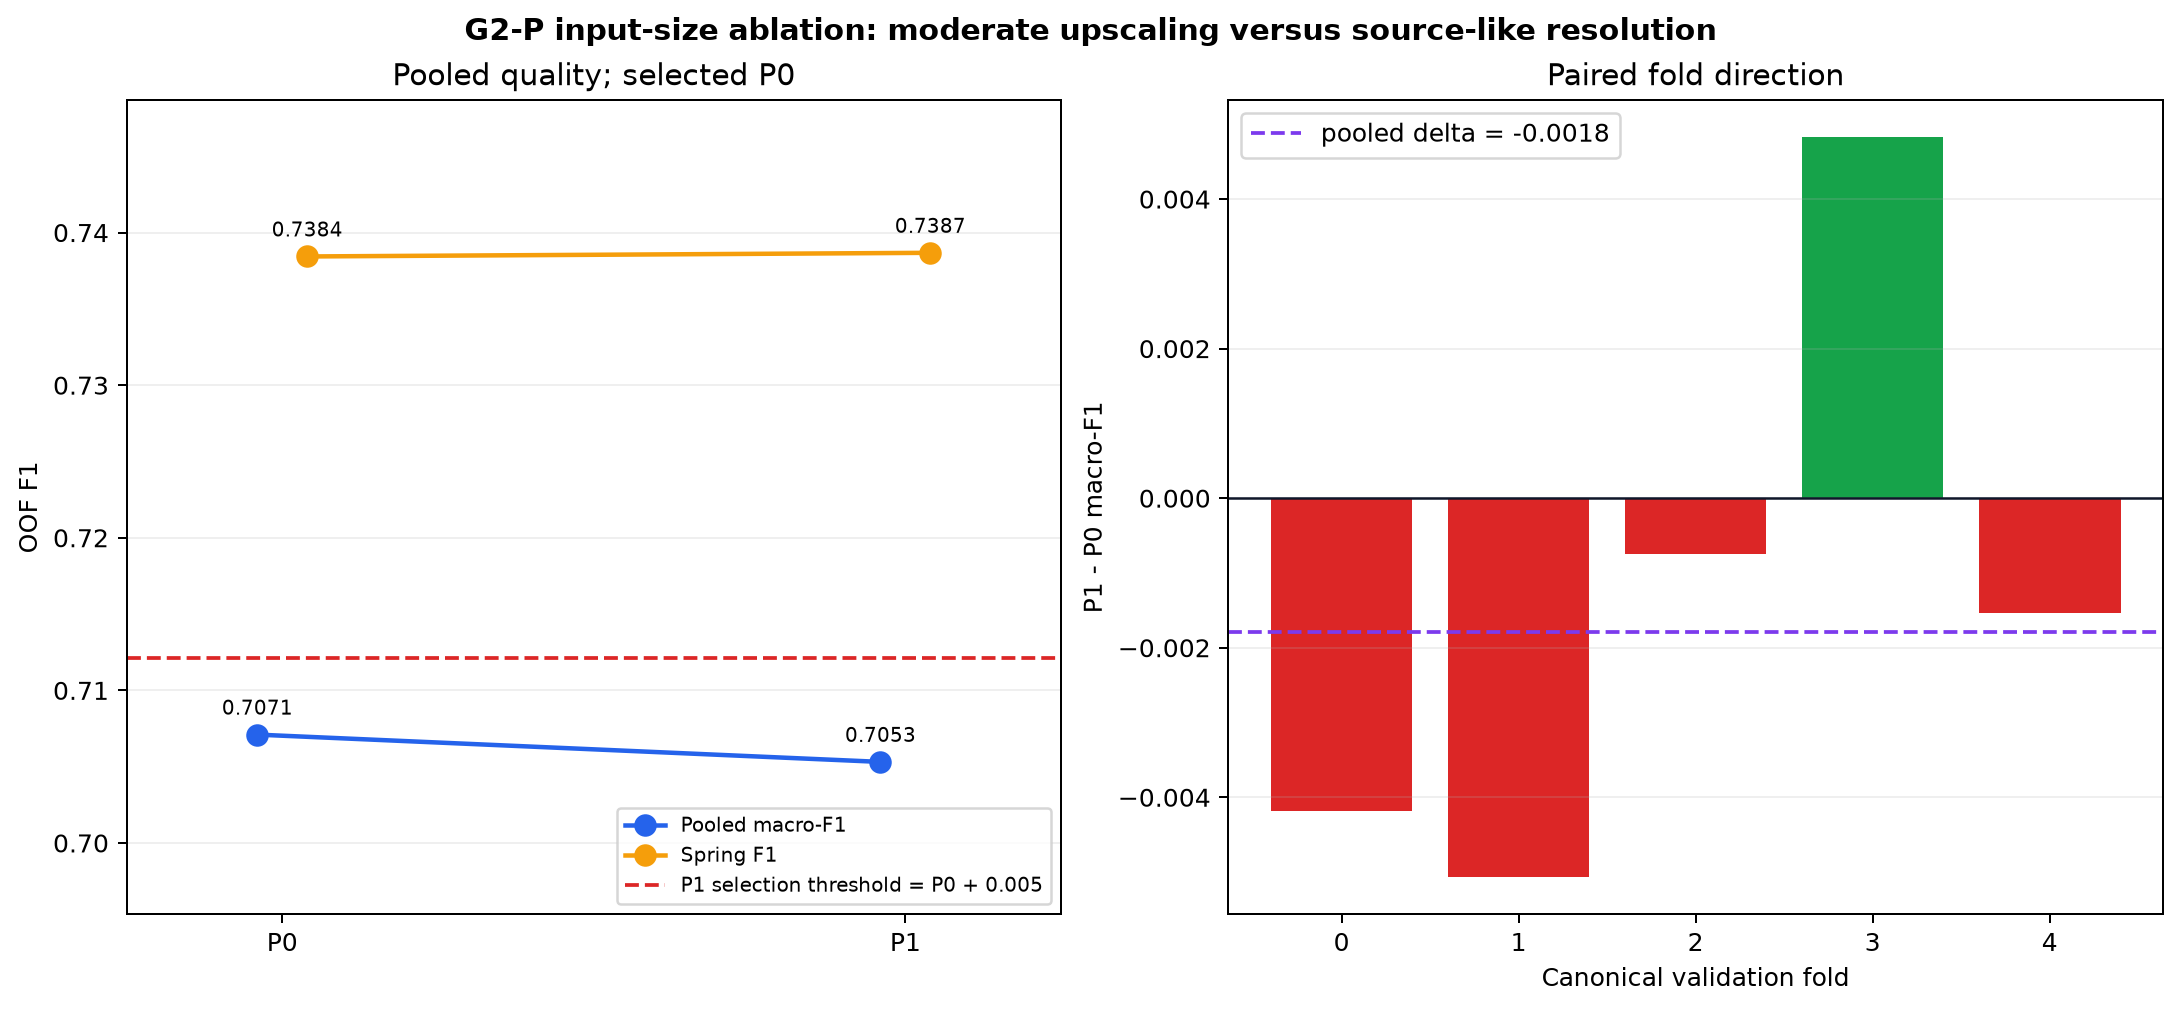

In [25]:
from fashion.task2.evidence import build_g2_input_size_evidence

g2_probability_note = (
    "Softmax probabilities come from each fold's best validation macro-F1 "
    "checkpoint. They are uncalibrated until the dedicated cross-fitted "
    "calibration gate, so current NLL, Brier, and ECE are diagnostics only."
)
g2_p1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "g2_p1_c2_resnet18.json",
    mode="run_or_load",
)
g2_p1_manifest = build_experiment_evidence(
    g2_p1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=g2_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_p1_c2_resnet18",
    figure_directory=TASK2_FIGURE_DIR,
)
assert g2_p1_manifest["coverage"]["row_count"] == len(season_development)
assert g2_p1_manifest["coverage"]["protected_id_count"] == 0
assert len(g2_p1_manifest["run_ids"]) == 5

g2_size_manifest = build_g2_input_size_evidence(
    p0_manifest_path=TASK2_EVIDENCE_DIR / "g1_c2_resnet18/manifest.json",
    p1_manifest_path=TASK2_EVIDENCE_DIR / "g2_p1_c2_resnet18/manifest.json",
    p0_config_path=TASK2_CONFIG_DIR / "g1_c2_resnet18.json",
    p1_config_path=TASK2_CONFIG_DIR / "g2_p1_c2_resnet18.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_input_size_ablation",
    figure_directory=TASK2_FIGURE_DIR,
)
g2_size_comparison = pd.read_csv(
    ROOT / g2_size_manifest["artifacts"]["comparison"]["path"]
)
g2_size_paired_folds = pd.read_csv(
    ROOT / g2_size_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
with (ROOT / g2_size_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_size_decision = json.load(handle)
assert g2_size_decision["selected_variant"] == "P0"
assert g2_size_decision["minimum_gain"] == 0.005

g2_p1_attempts = RunRegistry(RUNS_CSV).find(
    experiment_id="g2-p1-c2-resnet18"
)
assert len(g2_p1_attempts.loc[g2_p1_attempts["status"].eq("completed")]) == 5
assert not g2_p1_attempts["status"].eq("running").any()
display(
    g2_size_comparison.style.format(
        {
            "pooled_macro_f1": "{:.6f}",
            "fold_sd_macro_f1": "{:.6f}",
            "spring_f1": "{:.6f}",
            "delta_vs_p0_macro_f1": "{:+.6f}",
            "delta_vs_p0_spring_f1": "{:+.6f}",
            "five_fold_runtime_minutes": "{:.2f}",
            "peak_vram_mb": "{:.1f}",
            "runtime_ratio_vs_p0": "{:.3f}",
            "peak_vram_ratio_vs_p0": "{:.3f}",
        }
    )
)
display(
    g2_size_paired_folds.loc[:, [
        "fold",
        "p0_run_id",
        "p1_run_id",
        "p0_macro_f1",
        "p1_macro_f1",
        "delta_p1_minus_p0_macro_f1",
        "runtime_ratio_p1_vs_p0",
    ]]
)
display(
    g2_p1_attempts.loc[:, [
        "run_id",
        "fold",
        "status",
        "git_commit",
        "git_dirty",
        "error_type",
        "started_at_utc",
    ]].sort_values(["fold", "started_at_utc"])
)
display(
    Image(filename=str(ROOT / g2_size_manifest["artifacts"]["figure"]["path"]))
)

> **Interpretation:** **Result:** P0 `(80, 60)` achieved `0.707099` pooled five-fold OOF macro-F1 (fold SD `0.003872`; Spring F1 `0.738433`). P1 `(128, 96)` achieved `0.705312` (SD `0.006467`; Spring F1 `0.738673`). The P1-minus-P0 pooled delta was `-0.001787` (-0.179 percentage points), and four of five paired fold deltas favoured P0; only fold 3 favoured P1 (`+0.004827`). P1's Spring gain was only `+0.000239` (+0.024 points). P1 took `58.18` training minutes versus `29.21` for P0 (`1.992` times) and peaked at `1,321.9` MB versus `606.4` MB VRAM (`2.180` times), with the same `11,170,884` parameters. **Meaning:** moderate upscaling added interpolation and almost doubled measured training cost without adding pooled discrimination. **Decision:** retain P0 because P1 did not meet the frozen `+0.005` macro-F1 rule; run A0 versus A1 on C2 at `(80, 60)`. **Limitation:** this is an eight-epoch, one-seed transform screen; its softmax outputs are uncalibrated and it does not replace later robustness analysis. **Trace:** `results/evidence/task2/g2_input_size_ablation/manifest.json` hashes both configs, both experiment manifests, the paired-fold table, decision, and figure. P1 evidence runs were `g2-p1-c2-resnet18-f0-s2753-67217738d381`, `g2-p1-c2-resnet18-f1-s2753-66a1b27539dc`, `g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1`, `g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02`, and `g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4`. Three non-evidence attempts remain visible in the local registry: `g2-p1-c2-resnet18-f1-s2753-7327d09ce2cf` and `g2-p1-c2-resnet18-f1-s2753-dce57b0c7883` were interrupted; `g2-p1-c2-resnet18-f1-s2753-48ece6ab6852` failed because the first Windows background runner lacked a safe `__main__` guard. None enters the five completed OOF rows.

#### 8.2.2 A0 versus A1 augmentation

This ablation tests whether mild colour jitter helps generalisation without erasing genuine seasonal colour cues.

In [ ]:
# TODO:
# - Run A0=mild geometry versus A1=A0 plus mild colour jitter using the selected input size.
# - Hold model, seed, folds, budget, and optimisation settings constant.
# - Save overall, per-class, and robustness differences.
#
# Expected output:
# - One controlled augmentation table.
# - Spring and colour-sensitive class evidence.

> **Interpretation to write after running:** Explain whether colour jitter improves robustness or removes useful Season information.

#### 8.2.3 Compact finalist tuning

A small predeclared search avoids an open-ended hunt for a lucky configuration.

In [ ]:
# TODO:
# - Run exactly the three frozen learning-rate and weight-decay pairs on finalists.
# - Keep all other variables fixed and use the same five folds.
# - Select with the frozen primary metric and tie rule.
#
# Expected output:
# - A three-row tuning table per finalist.
# - One justified configuration without post-result search expansion.

> **Interpretation to write after running:** Explain the sensitivity to tuning and whether the gain is large enough to matter.

### 8.3 G4 problem-driven improvements and benchmark

Class balance, multi-task learning, and pretrained comparison test different hypotheses and are separated below.

#### 8.3.1 I1 class-balanced loss

I1 directly tests whether fold-fitted reweighting improves the Spring minority.

In [ ]:
# TODO:
# - Fit class-balanced weights independently inside every training fold.
# - Run the selected scratch architecture over all five folds with all other settings fixed.
# - Save overall and per-class OOF evidence.
#
# Expected output:
# - Complete I1 OOF predictions and registry rows.
# - Spring recall/F1 change plus majority-class trade-offs.

> **Interpretation to write after running:** State whether I1 solves minority neglect and whether it harms other classes or calibration.

#### 8.3.2 I2 image-only multi-task training

I2 tests whether auxiliary ArticleType supervision improves shared visual features or causes negative transfer.

In [ ]:
# TODO:
# - Train Season as the main target and ArticleType as the auxiliary target for lambda 0.1 and 0.3.
# - Keep inference image-only and never pass true ArticleType at prediction time.
# - Measure overall, Spring, and ArticleType aligned/conflict performance.
#
# Expected output:
# - Two complete lambda comparisons.
# - Negative-transfer and shortcut-conflict evidence.

> **Interpretation to write after running:** Explain whether auxiliary supervision helps genuine Season learning or strengthens the ArticleType shortcut.

#### 8.3.3 P* pretrained benchmark execution

P* estimates the value of transferred representation while remaining ineligible for submission.

In [ ]:
# TODO:
# - Run the predeclared pretrained ResNet benchmark with benchmark_only=true and scratch=false.
# - Match folds, input, budget, and metric as closely as the comparison permits.
# - Keep it outside the eligible winner table.
#
# Expected output:
# - A traceable pretrained comparison result.
# - Visible final_eligible=false in every artifact.

> **Interpretation to write after running:** Explain the representation-learning gap without treating P* as a permitted final model.

### 8.4 G5 second-seed stability

A second seed checks whether the final ordering depends on random initialisation.

In [ ]:
# TODO:
# - Run the final two eligible candidates with a second frozen seed over all five folds.
# - Compare candidate ordering, per-fold spread, Spring recall, and runtime across seeds.
# - Save the stability table to results/evidence/task2/seed_stability.csv.
#
# Expected output:
# - Ten additional finalist runs and one seed-stability table.
# - A documented stable result or an honest reversal.

> **Interpretation to write after running:** State whether the winner is stable. If ordering reverses, reduce the strength of the final claim.

## 9. Cross-validated results

Turn registry-backed OOF artifacts into the main comparison evidence.

### 9.1 OOF leaderboard and fold stability

The leaderboard must be generated from artifacts, not typed by hand.

In [ ]:
# TODO:
# - Load complete eligible runs and OOF predictions from the registry.
# - Verify 32,753 unique predictions for each compared configuration.
# - Calculate pooled OOF macro-F1, accuracy, and balanced accuracy.
# - Calculate fold mean/SD, runtime, and parameter count.
# - Save and display results/evidence/task2/model_leaderboard.csv.
#
# Expected output:
# - One sorted scorecard covering quality, stability, and cost.
# - No incomplete run or benchmark-only model mixed into final eligibility.

> **Interpretation to write after running:** Describe the meaningful differences, not just the top row. Mention spread, cost, and any near-tie.

### 9.2 Per-class performance and confusion matrices

Per-class evidence shows whether overall improvement is real or only comes from Summer.

In [ ]:
# TODO:
# - Calculate precision, recall, F1, and support for all four labels in fixed order.
# - Create count and row-normalised confusion matrices for finalists.
# - Save the table and report-ready figures under the Task 2 evidence directories.
#
# Expected output:
# - A complete four-class metric table.
# - Readable confusion matrices with traceable run IDs.

> **Interpretation to write after running:** Name the largest confusion pairs and explain whether Spring improved or remained the main limitation.

### 9.3 Calibration and learning behaviour

Confidence quality and epoch behaviour require different figures, so they are split below.

#### 9.3.1 Calibration and risk-coverage

Reliable confidence supports the app's human-review decision.

In [ ]:
# TODO:
# - Calculate NLL, multiclass Brier score, and reliability bins.
# - Calculate risk-coverage from finalist OOF probabilities.
# - Fit any temperature scalar from development OOF logits only.
# - Save calibration tables and report-ready figures.
#
# Expected output:
# - Reliability and risk-coverage evidence for finalists.
# - No holdout-fitted calibration.

> **Interpretation to write after running:** State whether confidence matches correctness and how a review threshold could be chosen.

#### 9.3.2 Learning curves and epoch behaviour

Train and validation curves explain whether the fixed budget and refit epoch rule are reasonable.

In [ ]:
# TODO:
# - Plot loss and frozen primary metric by epoch and fold for finalists.
# - Mark best epochs selected by the predeclared rule.
# - Calculate the median best epoch used for final refit.
#
# Expected output:
# - Traceable learning curves and a median-best-epoch value.
# - Evidence of underfit, overfit, or stable convergence.

> **Interpretation to write after running:** Explain the learning behaviour and justify the final refit epoch without using holdout.

## 10. Error and shortcut analysis

Test the exact weaknesses identified by EDA using OOF predictions only.

### 10.1 Spring and ArticleType shortcut slices

Minority-class failure and shortcut conflict are distinct analyses, so each has its own code cell.

#### 10.1.1 Spring minority analysis

Spring needs direct evidence because it represents only 4.06% of valid labels.

In [ ]:
# TODO:
# - Report Spring precision, recall, F1, confidence, and main confusion destinations for finalists.
# - Include support and changes from B0/B1 and the unweighted-loss model.
# - Save the Spring evidence table.
#
# Expected output:
# - Spring-specific quality and confidence metrics.
# - Traceable comparison across baseline, finalist, and I1.

> **Interpretation to write after running:** Explain whether the model still ignores Spring and which classes absorb its errors.

#### 10.1.2 ArticleType aligned versus conflict

The conflict slice tests whether image performance survives when the ArticleType shortcut is wrong.

In [ ]:
# TODO:
# - Fit ArticleType-to-Season majority mappings on each training fold only.
# - Split its validation rows into aligned and conflict groups after prediction.
# - Compare support, macro-F1, per-class recall, and confidence for finalists and I2.
#
# Expected output:
# - Aligned/conflict slice metrics with fold-fitted mappings.
# - No true ArticleType passed into the model.

> **Interpretation to write after running:** Explain whether improvements reflect broader visual learning or stronger ArticleType dependence.

### 10.2 Acquisition year and compression slices

Acquisition era and file compression are separate shortcut warnings and are analysed independently.

#### 10.2.1 Acquisition-year slice

The year slice tests the strong collection-era association found in development EDA.

In [ ]:
# TODO:
# - Compare 2011-2012 with all other years using metadata after prediction only.
# - Report support, macro-F1, per-class recall, and confidence.
# - Save the year-slice table with run IDs.
#
# Expected output:
# - Two year-group rows per finalist with support.
# - No year feature in model input.

> **Interpretation to write after running:** Describe any gap as acquisition-shortcut risk, not proof that year causes the prediction.

#### 10.2.2 Training-fitted file-size slice

File-size quartiles test sensitivity to compression traces without using file bytes as a feature.

In [ ]:
# TODO:
# - Fit file-size quartile boundaries inside each training fold.
# - Apply those boundaries to matching validation predictions.
# - Report support, macro-F1, per-class recall, and confidence by quartile.
#
# Expected output:
# - Fold-fitted boundaries and file-size slice metrics.
# - No global-development boundary fitted during CV.

> **Interpretation to write after running:** Explain whether the model is unusually dependent on heavily compressed images.

### 10.3 Family-size and image-mode slices

Related-product structure and rare image mode answer different generalisation questions.

#### 10.3.1 Product-family size slice

This slice checks whether results are stronger for products with related rows.

In [ ]:
# TODO:
# - Compare singleton with multi-row product_family_group members.
# - Report support, macro-F1, per-class recall, and uncertainty for finalists.
# - Keep family definitions exactly as delivered.
#
# Expected output:
# - Family-size metrics with support counts.
# - No claim that conservative groups are verified SKUs.

> **Interpretation to write after running:** State whether quality depends on related-product groups and how that limits generalisation.

#### 10.3.2 Greyscale versus RGB slice

Rare greyscale images may reveal colour dependence or transform problems.

In [ ]:
# TODO:
# - Use the existing structural audit field to separate greyscale and RGB validation images.
# - Report support, macro-F1, per-class recall, and confidence.
# - Attach uncertainty warnings to the small greyscale slice.
#
# Expected output:
# - Image-mode metrics with support.
# - A clear small-sample warning where required.

> **Interpretation to write after running:** Explain whether the result indicates colour reliance, while avoiding strong claims from the rare slice.

## 11. Robustness and efficiency

Measure controlled image degradation and the practical cost of the final candidates.

### 11.1 Deterministic perturbation tests

JPEG, brightness, and blur tests check whether mild real-world changes break the same frozen model.

In [ ]:
# TODO:
# - Evaluate unchanged images and JPEG quality 85 re-encoding.
# - Evaluate brightness -15%, brightness +15%, and blur radius 1.
# - Reuse the frozen model and preprocessing; do not tune on degraded views.
# - Report absolute metrics and drops from the unchanged images.
# - Save the robustness table and one report-ready figure.
#
# Expected output:
# - Deterministic perturbation results for each finalist.
# - A clear robustness drop for every controlled change.

> **Interpretation to write after running:** Explain which perturbation is most harmful and whether it changes the deployment recommendation.

### 11.2 Deployment cost

Inference latency and resource size use different measurement protocols, so they are separated below. Seed stability is already handled in Section 8.4.

#### 11.2.1 Batch-one inference latency

The app serves one uploaded image at a time, so batch-one timing is the relevant cost.

In [ ]:
# TODO:
# - Measure warmed CPU and GPU batch-one latency with p50 and p95 under one fixed protocol.
# - Use the exact frozen preprocessing and repeat enough times.
# - Save hardware, warm-up, repeat count, and timing results.
#
# Expected output:
# - Reproducible CPU/GPU p50 and p95 latency per finalist.
# - No training or data-loading time mixed into inference timing.

> **Interpretation to write after running:** State whether the latency is acceptable for interactive use and which model is fastest.

#### 11.2.2 Model and training resource cost

Model size, RAM/VRAM, and training time complete the practical comparison.

In [ ]:
# TODO:
# - Record parameter count, checkpoint bytes, peak RAM/VRAM, and total training time.
# - Join these values with the finalist scorecard by run ID.
# - Save results/evidence/task2/efficiency.csv.
#
# Expected output:
# - A traceable resource-cost table.
# - Measured values for every finalist.

> **Interpretation to write after running:** Explain whether a quality gain justifies its storage and compute cost.

## 12. Explainability and failure cases

Use deterministic examples to understand where the model looks and why it fails.

### 12.1 Select representative examples deterministically

Fixed selection prevents cherry-picking attractive successes or dramatic failures.

In [ ]:
# TODO:
# - Select three correct and three incorrect OOF examples per class.
# - Order candidates by confidence and then product ID.
# - Include high-confidence errors and low-confidence correct cases where available.
# - Save the selected ID list before viewing Grad-CAM.
#
# Expected output:
# - Up to 24 traceable examples with fixed selection reasons.
# - Balanced coverage of all four classes and both outcomes.

> **Interpretation to write after running:** Explain why the selection rule is fair and note any class with too few qualifying examples.

### 12.2 Generate Grad-CAM diagnostics

Grad-CAM can reveal whether the model attends to the product or to borders and background.

In [ ]:
# TODO:
# - Generate Grad-CAM for the frozen selected IDs and a declared convolutional layer.
# - Overlay maps on the original aspect-preserved images.
# - Save one contact sheet per class with true label, prediction, confidence, and run ID.
#
# Expected output:
# - Traceable Grad-CAM sheets for correct and incorrect cases.
# - No causal claim based only on a heatmap.

> **Interpretation to write after running:** Describe recurring attention patterns and whether shortcut-like border/background focus appears.

### 12.3 Build the failure taxonomy

The rubric rewards honest analysis of limitations, not only successful examples.

In [ ]:
# TODO:
# - Review the deterministic cases and assign the fixed failure taxonomy.
# - Use ambiguity, weak data, shortcut, transform, imbalance, or model limitation.
# - Create a contact sheet with ID, labels, confidence, ArticleType, year group, and short note.
# - Save the taxonomy table and report-ready figure.
#
# Expected output:
# - A failure table with real IDs and balanced examples.
# - At least one honest limitation supported by evidence.

> **Interpretation to write after running:** Separate data limitations from model limitations and state which failure type matters most in real use.

## 13. Statistical and external comparison

Measure uncertainty between finalists and compare literature only when assumptions are made explicit.

### 13.1 Paired family bootstrap

Rows inside a product family may be related, so uncertainty should preserve those blocks.

In [ ]:
# TODO:
# - Pair finalist OOF predictions by product ID.
# - Bootstrap product_family_group blocks with the frozen seed and enough resamples.
# - Calculate the 95% interval for the macro-F1 difference and save the bootstrap distribution.
# - Mark the interval as conservative because family groups are not verified SKUs.
#
# Expected output:
# - A paired difference estimate, 95% interval, and distribution figure.
# - No independent-row bootstrap.

> **Interpretation to write after running:** State whether the evidence clearly separates finalists or supports the predeclared near-tie rule.

### 13.2 Qualified literature comparison

Published work uses different targets, splits, pretraining, resolution, or multimodal inputs, so scores are not direct benchmarks.

In [ ]:
# TODO:
# - Build a comparison table for the cited ResNet-BERT and Condition-CNN studies.
# - Record dataset, target, split, image resolution, pretraining, input modalities, and metric.
# - Mark score comparability as no unless every condition matches.
# - Save the table for the report appendix.
#
# Expected output:
# - A transparent assumptions table with authoritative citations.
# - No claim that unlike scores are directly equal.

> **Interpretation to write after running:** Explain what can be learned from the papers and why their numeric results cannot validate this exact Season task.

## 14. Ultimate Judgement and freeze

Apply the predeclared rule, reject alternatives explicitly, and freeze all choices before holdout.

### 14.1 Apply the final decision scorecard

The selected model must balance class quality, robustness, calibration, and deployment cost.

In [ ]:
# TODO:
# - Join leaderboard, shortcut, robustness, and calibration evidence by run ID.
# - Add bootstrap and efficiency evidence.
# - Apply the frozen ranking and near-tie rule without changing weights after viewing results.
# - Record the winner, every rejected alternative, evidence, cost, and limitation.
# - Save results/evidence/task2/ultimate_judgement.csv.
#
# Expected output:
# - One complete scorecard and one eligible scratch-trained winner.
# - Explicit reasons for rejecting every finalist and improvement.

> **Interpretation to write after running:** Write the final evidence-backed judgement in plain language, including the strongest limitation and the practical trade-off.

### 14.2 Write the freeze manifest

The manifest proves that model choices were locked before independent evaluation.

In [ ]:
# TODO:
# - Freeze run ID, config hash, split digest, labels, transform, and loss.
# - Freeze seed, metric, epoch, checkpoint, and calibration rules.
# - Record the decision timestamp and hash the manifest.
# - Save results/evidence/task2/freeze_manifest.json and display it.
#
# Expected output:
# - A complete, hashed, immutable freeze record.
# - No holdout metric or holdout-derived choice.

> **Interpretation to write after running:** Confirm that Notebook 06 can evaluate this exact decision without any remaining modelling choice.

### 14.3 Refit the frozen model on all development data

Final refit uses all labelled development rows only after CV selection is complete.

In [ ]:
# TODO:
# - Refit fold-learned preprocessing values and class weights on all valid development rows.
# - Train the frozen scratch configuration for the median best epoch from CV.
# - Apply development-OOF temperature scaling if it was selected.
# - Save models/task2_season.pt plus config, label map, and hashes.
#
# Expected output:
# - One final scratch-trained checkpoint and inference bundle.
# - Hashes matching the freeze manifest and no holdout-based early stopping.

> **Interpretation to write after running:** State the exact refit rule and verify that nothing was changed after the freeze.

## 15. Handoff to final evaluation

Audit every artifact and hand the frozen Task 2 component to Notebook 06 without opening holdout here.

### 15.1 Audit final artifacts and notebook evidence

Artifact traceability and clean notebook export are separate final checks.

#### 15.1.1 Artifact and traceability audit

Every final claim must map back to a run, configuration, prediction file, table, figure, or checkpoint.

In [ ]:
# TODO:
# - Check registry completeness, OOF coverage, and figure/table paths.
# - Check checkpoint hashes and inference smoke tests.
# - Verify that report numbers are generated rather than hand-copied.
# - Display a pass/fail definition-of-done checklist.
#
# Expected output:
# - All Task 2 artifacts exist and hashes match.
# - No missing run-to-claim link.

> **Interpretation to write after running:** List any unresolved artifact. The handoff remains blocked until all required evidence passes.

#### 15.1.2 Clean Run All and HTML export

A fresh execution proves that Notebook 03 is reproducible and presentation-ready.

In [ ]:
# TODO:
# - Restart the kernel and run all cells in order in the locked environment.
# - Check for stale outputs, hidden state, errors, and manual result edits.
# - Export results/notebooks/03_task2_season.html and record its digest.
#
# Expected output:
# - A clean successful Run All.
# - A fresh HTML export with a traceable digest.

> **Interpretation to write after running:** Confirm that the notebook is self-contained as a narrative and that every displayed result was regenerated.

### 15.2 Verify the sealed-holdout handoff

Notebook 03 prepares the final model but must never open protected evaluation labels.

In [ ]:
# TODO:
# - Assert that this notebook used only redacted loaders and development OOF evidence.
# - Package the frozen checkpoint, manifest, inference function, and allowed labels.
# - Include unresolved risks for Notebook 06.
# - Display the handoff summary with status READY only when every audit passes.
#
# Expected output:
# - A complete Notebook 06 handoff with holdout still sealed.
# - No holdout metric, prediction, or model change in this notebook.

> **Interpretation to write after running:** State whether the handoff is ready and name the remaining risks that Notebook 06 must report after its single evaluation.